In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))
from game import RepeatedReferenceGame, Trial
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import re

plt.rcParams['figure.dpi'] = 300

In [2]:
from nltk.tokenize import word_tokenize as tokenize
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from nltk.stem.porter import *
stemmer = PorterStemmer()

In [4]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [5]:
def editDistance(h, r, sent_len=None):
    #Reference: https://github.com/zszyellow/WER-in-python/blob/master/wer.py
    '''
    This function is to calculate the edit distance of reference sentence and the hypothesis sentence.

    Main algorithm used is dynamic programming.

    Attributes: 
        r -> the list of words produced by splitting reference sentence.
        h -> the list of words produced by splitting hypothesis sentence.
    '''
    d = np.zeros((len(r)+1)*(len(h)+1), dtype=np.uint8).reshape((len(r)+1, len(h)+1))
    for i in range(len(r)+1):
        d[i][0] = i
    for j in range(len(h)+1):
        d[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            if r[i-1] == h[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                substitute = d[i-1][j-1]+1
                insert = d[i][j-1]+1 
                delete = d[i-1][j]
                d[i][j] = min(substitute, insert, delete)
    # d=d[len(r)][len(h)]/len(r)
    d=d[len(r)][len(h)]
    
    if len(r)!=0:
        wnr=d/len(r)
        
    else:
        wnr=1 

    return d, wnr

def get_msg_distance(sentences):
 
    lemmatized_sentences = []
    sentences_lemma=[]
    for sentence in sentences:
        sentence = sentence.strip().strip('.').lower()
        doc = nlp(sentence)
        
     
        filtered_sentence_lemma = []
        for token in doc:
            if token.pos_ in ["NOUN", "ADJ", "VERB", "ADV", 'PROPN','NUM','PRON','ADP']:
                token_lemma=token.lemma_
                filtered_sentence_lemma.append(token_lemma)
          
        lemmatized_sentences.append(' '.join(filtered_sentence_lemma))
        sentences_lemma.append(filtered_sentence_lemma)
    


    wnd, wnr=editDistance(sentences_lemma[1], sentences_lemma[0])



    return wnd, wnr

In [6]:
def snd(utterance_list):
    if len(utterance_list) == 1:
        return 0

    processed = [[stemmer.stem(w) for w in tokenize(u.lower()) if w not in stop_words and (w.islower() or w.isalnum())] for u in utterance_list]
    utterance_W = []
    for i, utterance in enumerate(processed):
        token_W = []
        for j, token in enumerate(utterance):
            denominator = len(utterance_list) - 1
            num_unseen = 0
            for k, alt_utterance in enumerate(processed):
                if i == k:
                    continue
                k_tokens = set(alt_utterance)
                if token not in k_tokens:
                    num_unseen += 1
            token_W.append(num_unseen / denominator)
        utterance_W.append(np.mean(token_W))
    return np.mean(utterance_W).item()

In [7]:
with open("full_SND.json") as f:
    snd_data = json.load(f)

In [45]:
df_list = list()
for i, results_file in enumerate(Path("../pixtral_results").glob("*.json")):
    print(i, results_file.name)
    speaker = re.search(r"speaker=([^-\.]+)", results_file.name).group(1)
    listener = re.search(r"listener=([^-\.]+)", results_file.name).group(1)
    if "prompt_type" in results_file.name:
        prompt_type = re.search(r"prompt_type=([^-\.]+)", results_file.name).group(1)
    else:
        prompt_type = "standard"
    
    if "temperature" in results_file.name:
        speaker_temp = re.search(r"temperature=([^-]+)", results_file.name).group(1)
    else:
        speaker_temp = 0.7 if "joint_inference" in speaker else 0.3

    if "num_speaker_samples" in results_file.name:
        n_speaker_samples = int(re.search(r"num_speaker_samples=([^-\.]+)", results_file.name).group(1))
    else:
        n_speaker_samples = 5
    
    if "lambda" in results_file.name:
        listener_lambda = float(re.search(r"lambda=([^-]+)", results_file.name).group(1))
    else:
        listener_lambda = 0.5 if "joint_inference" in listener else 1.0

    if "feedback_label" in results_file.name:
        feedback_label = re.search(r"feedback_label=([^-\.]+)", results_file.name).group(1)
    else:
        feedback_label = "false"

    if "context=" in results_file.name:
        listener_context_type = re.search(r"context=([^-\.]+)", results_file.name).group(1)
    else:
        listener_context_type = None
    with results_file.open('r') as f:
        for gameid, game in json.load(f).items():
            rrg = RepeatedReferenceGame.model_validate_json(json.dumps(game))
            block_counter = Counter()
            target_utterances = defaultdict(list)
            prev_block_num_words = defaultdict(int)
            prev_block_correct = defaultdict(bool)
            for trial_idx, trial in enumerate(rrg.trials):
                block_counter[trial.target] += 1
                if trial.message:
                    target_utterances[trial.target].append(trial.message)
                num_raw_words = len(trial.message.split()) if trial.message else 0
                wnd, wnr = get_msg_distance([target_utterances[trial.target][-1], trial.message]) if len(target_utterances[trial.target]) > 0 and trial.message else (0, 0)
                df_list.append({
                    "condition": i,
                    "speaker": speaker if speaker != "scoring" else "generate",
                    "listener": listener if speaker != "scoring" else "scoring",
                    "prompt_type": prompt_type,
                    "listener_context_type": listener_context_type,
                    "feedback_label": feedback_label,
                    "speaker_temp": speaker_temp,
                    "listener_lambda": listener_lambda,
                    "n_speaker_samples": n_speaker_samples,
                    "gameid": gameid,
                    "trial_idx": trial_idx,
                    "target": trial.target,
                    "block_idx": block_counter[trial.target],
                    "num_raw_words": num_raw_words,
                    "correct": trial.correct,
                    "kilogram_snd": snd_data[trial.target.split('.')[0]],
                    "prev_block_correct": prev_block_correct[trial.target],
                    "prev_block_num_words": prev_block_num_words[trial.target],
                    "feedback_adaptation_ratio": np.log(num_raw_words / prev_block_num_words[trial.target]) if prev_block_num_words[trial.target] > 0 else None,
                    "wnd": wnd,
                    "wnr": wnr,
                    # "snd": snd(target_utterances[trial.target])
                })

                prev_block_correct[trial.target] = trial.correct
                prev_block_num_words[trial.target] = len(trial.message.split()) if trial.message else 0

df = pd.DataFrame(df_list)

0 speaker=joint_inference_block_shuffle-temperature=0.3-num_speaker_samples=25-listener=joint_inference-lambda=0.5-context=block_shuffle.json
1 speaker=splice_1-listener=joint_inference-context=block_shuffle.json


/tmp/ipykernel_3681989/4283885284.py:67: RuntimeWarning: divide by zero encountered in log
  "feedback_adaptation_ratio": np.log(num_raw_words / prev_block_num_words[trial.target]) if prev_block_num_words[trial.target] > 0 else None,


2 speaker=human-listener=joint_inference-lambda=0.1-context=block_shuffle.json
3 speaker=generate_explicit-listener=generate-context=block_shuffle.json
4 speaker=human-listener=joint_inference-lambda=0.9-context=block_shuffle.json
5 speaker=human-listener=joint_inference-lambda=1.0-context=block_shuffle.json
6 speaker=scoring-listener=generate-context=once.json
7 speaker=human-listener=generate-context=block_shuffle.json
8 speaker=human-listener=joint_inference-lambda=0.8-context=block_shuffle.json
9 speaker=joint_inference_block_shuffle-num_speaker_samples=25-listener=joint_inference-lambda=0.6-context=block_shuffle.json
10 speaker=splice_2-listener=joint_inference-context=block_shuffle.json
11 speaker=splice_3-listener=joint_inference-context=block_shuffle.json
12 speaker=splice_2-listener=generate-context=block_shuffle.json
13 speaker=human-listener=joint_inference-lambda=0.0-context=block_shuffle.json
14 speaker=human-listener=joint_inference-context=once.json
15 speaker=joint_infe

In [31]:
df[(df.speaker == "joint_inference_block_shuffle")&(df.listener=="joint_inference")&(df.listener_lambda == 0.5)].condition.unique()

array([ 0, 19, 31, 35])

In [ ]:
df.speaker.unique()

In [ ]:
df.listener.unique()

Text(0.5, 1.0, 'Human speaker / Pixtral listener')

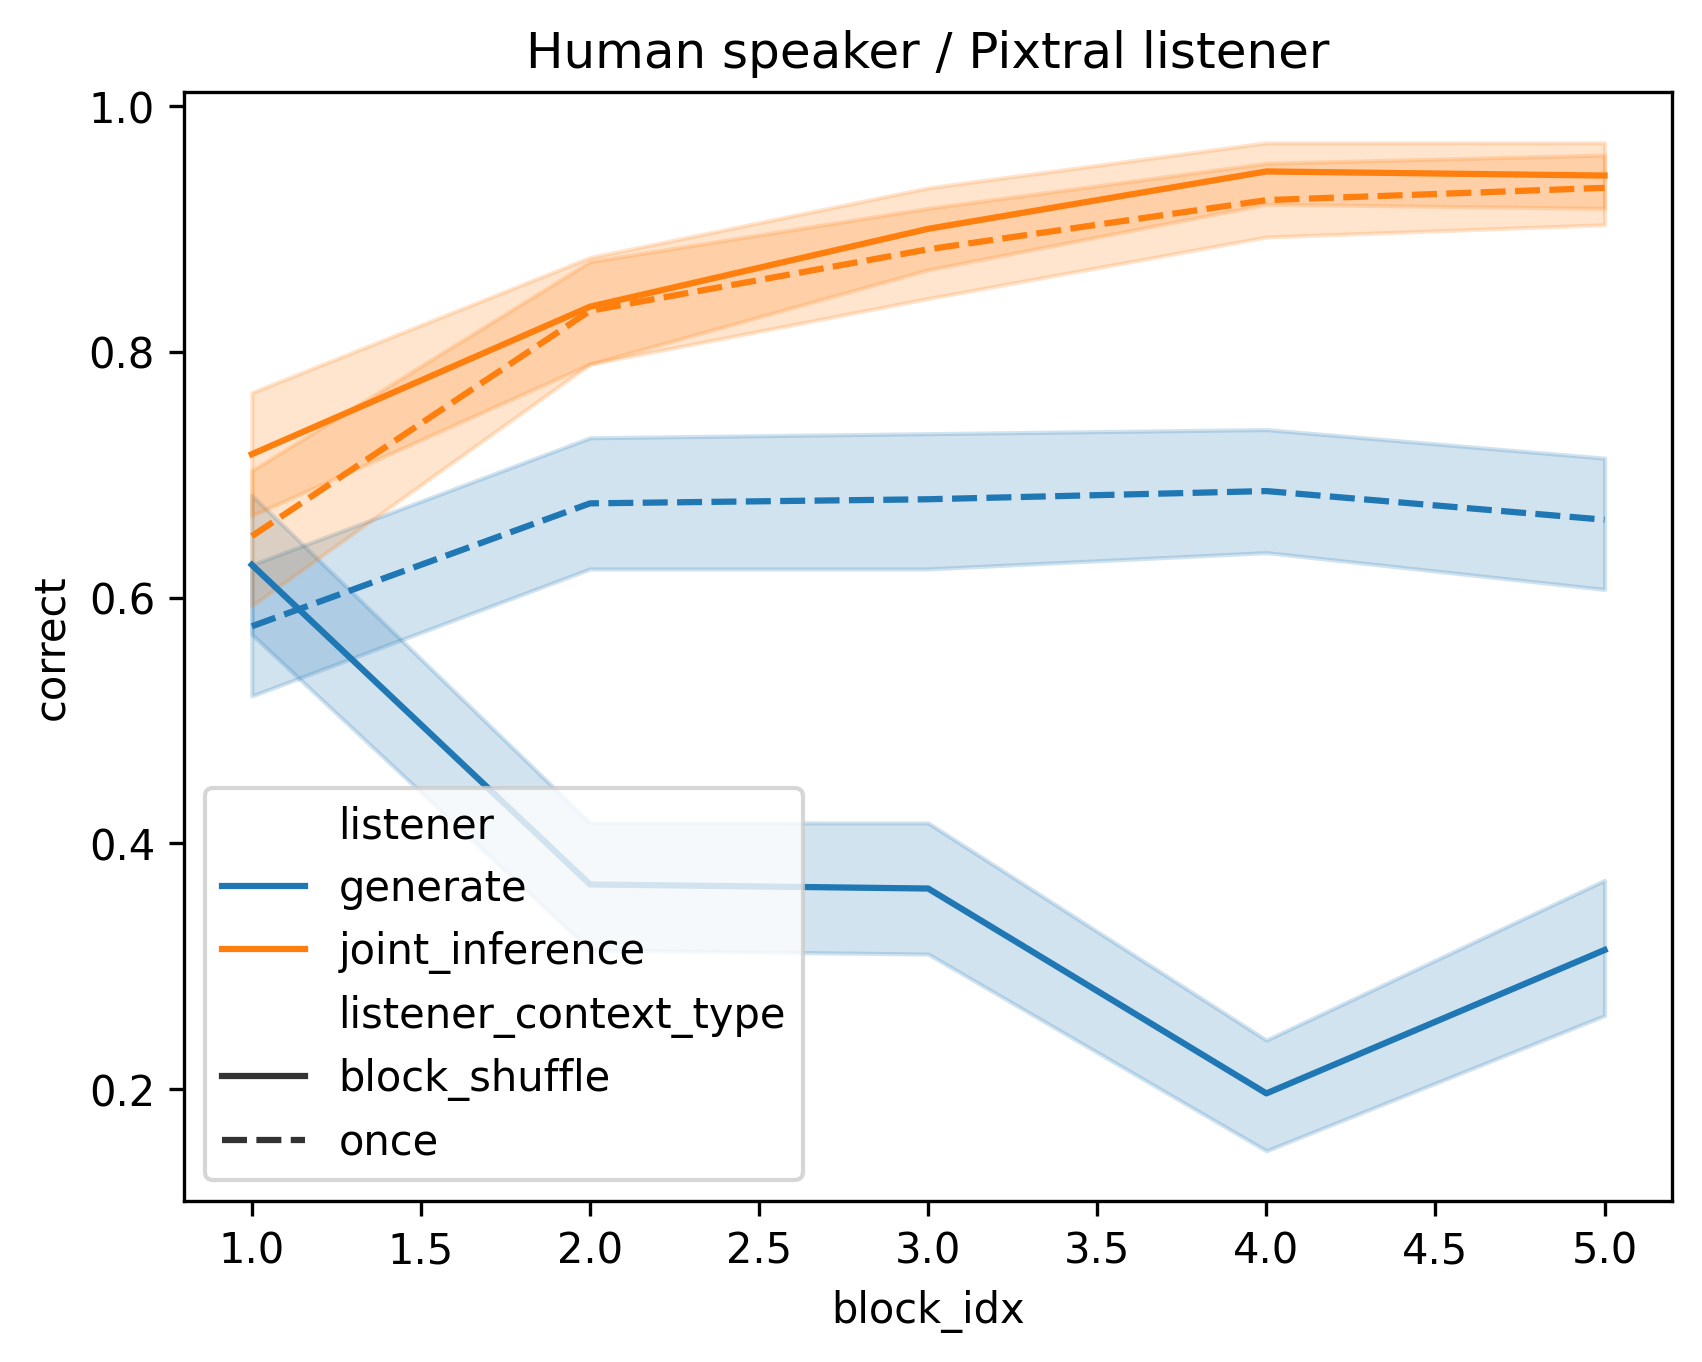

In [12]:
sns.lineplot(data=df[df.condition.isin([7, 22, 14, 23])], x="block_idx", y="correct", style="listener_context_type", hue="listener")
plt.title("Human speaker / Pixtral listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([2, 4, 7])], x="block_idx", y="correct", hue="listener_context_type", style="prompt_type")
plt.title("Human speaker / Joint inference listener")

Text(0.5, 1.0, 'Human speaker (spliced) / Pixtral listener')

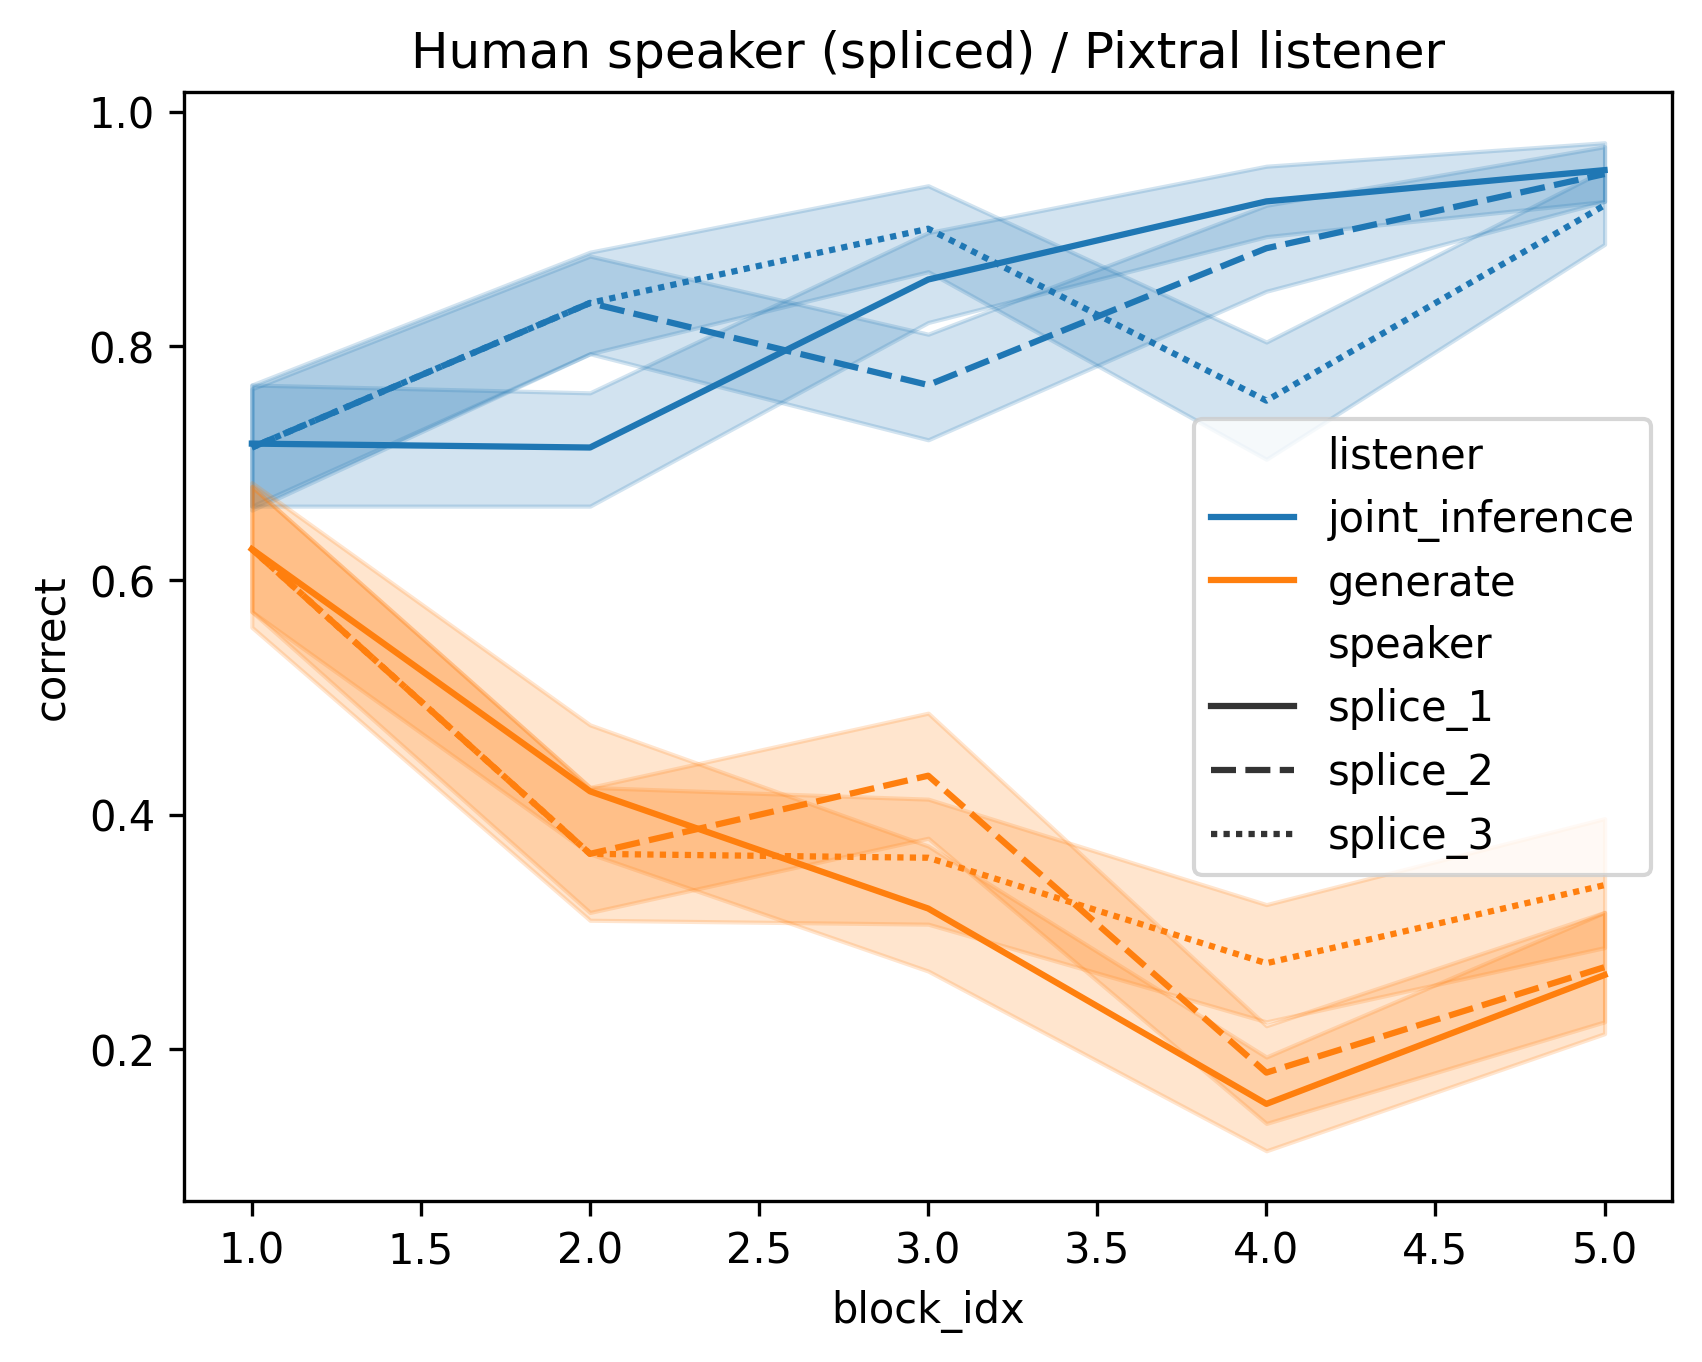

In [17]:
sns.lineplot(data=df[df.condition.isin([1, 27, 10, 12, 11, 16])], x="block_idx", y="correct", style="speaker", hue="listener")
plt.title("Human speaker (spliced) / Pixtral listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([8, 12, 13, 11, 5])], x="block_idx", y="correct", hue="speaker")
plt.title("Pixtral speaker / Pixtral listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([8, 12, 13, 11, 5])], x="block_idx", y="num_raw_words", hue="speaker")
plt.title("Pixtral speaker / Pixtral listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([8, 12, 13, 11, 5])], x="block_idx", y="snd", hue="speaker")
plt.title("Pixtral speaker / Pixtral listener")

/tmp/ipykernel_3681989/3653282699.py:2: UserWarning: The palette list has more values (12) than needed (11), which may not be intended.
  ax = sns.lineplot(data=df[df.condition.isin([ 2,  4,  5,  8, 13, 17, 20, 28, 30, 36, 40, 7])], x="block_idx", y="correct", hue="listener_lambda", style="listener", palette=custom_palette)


Text(0.5, 1.0, 'Human speaker / Pixtral listener')

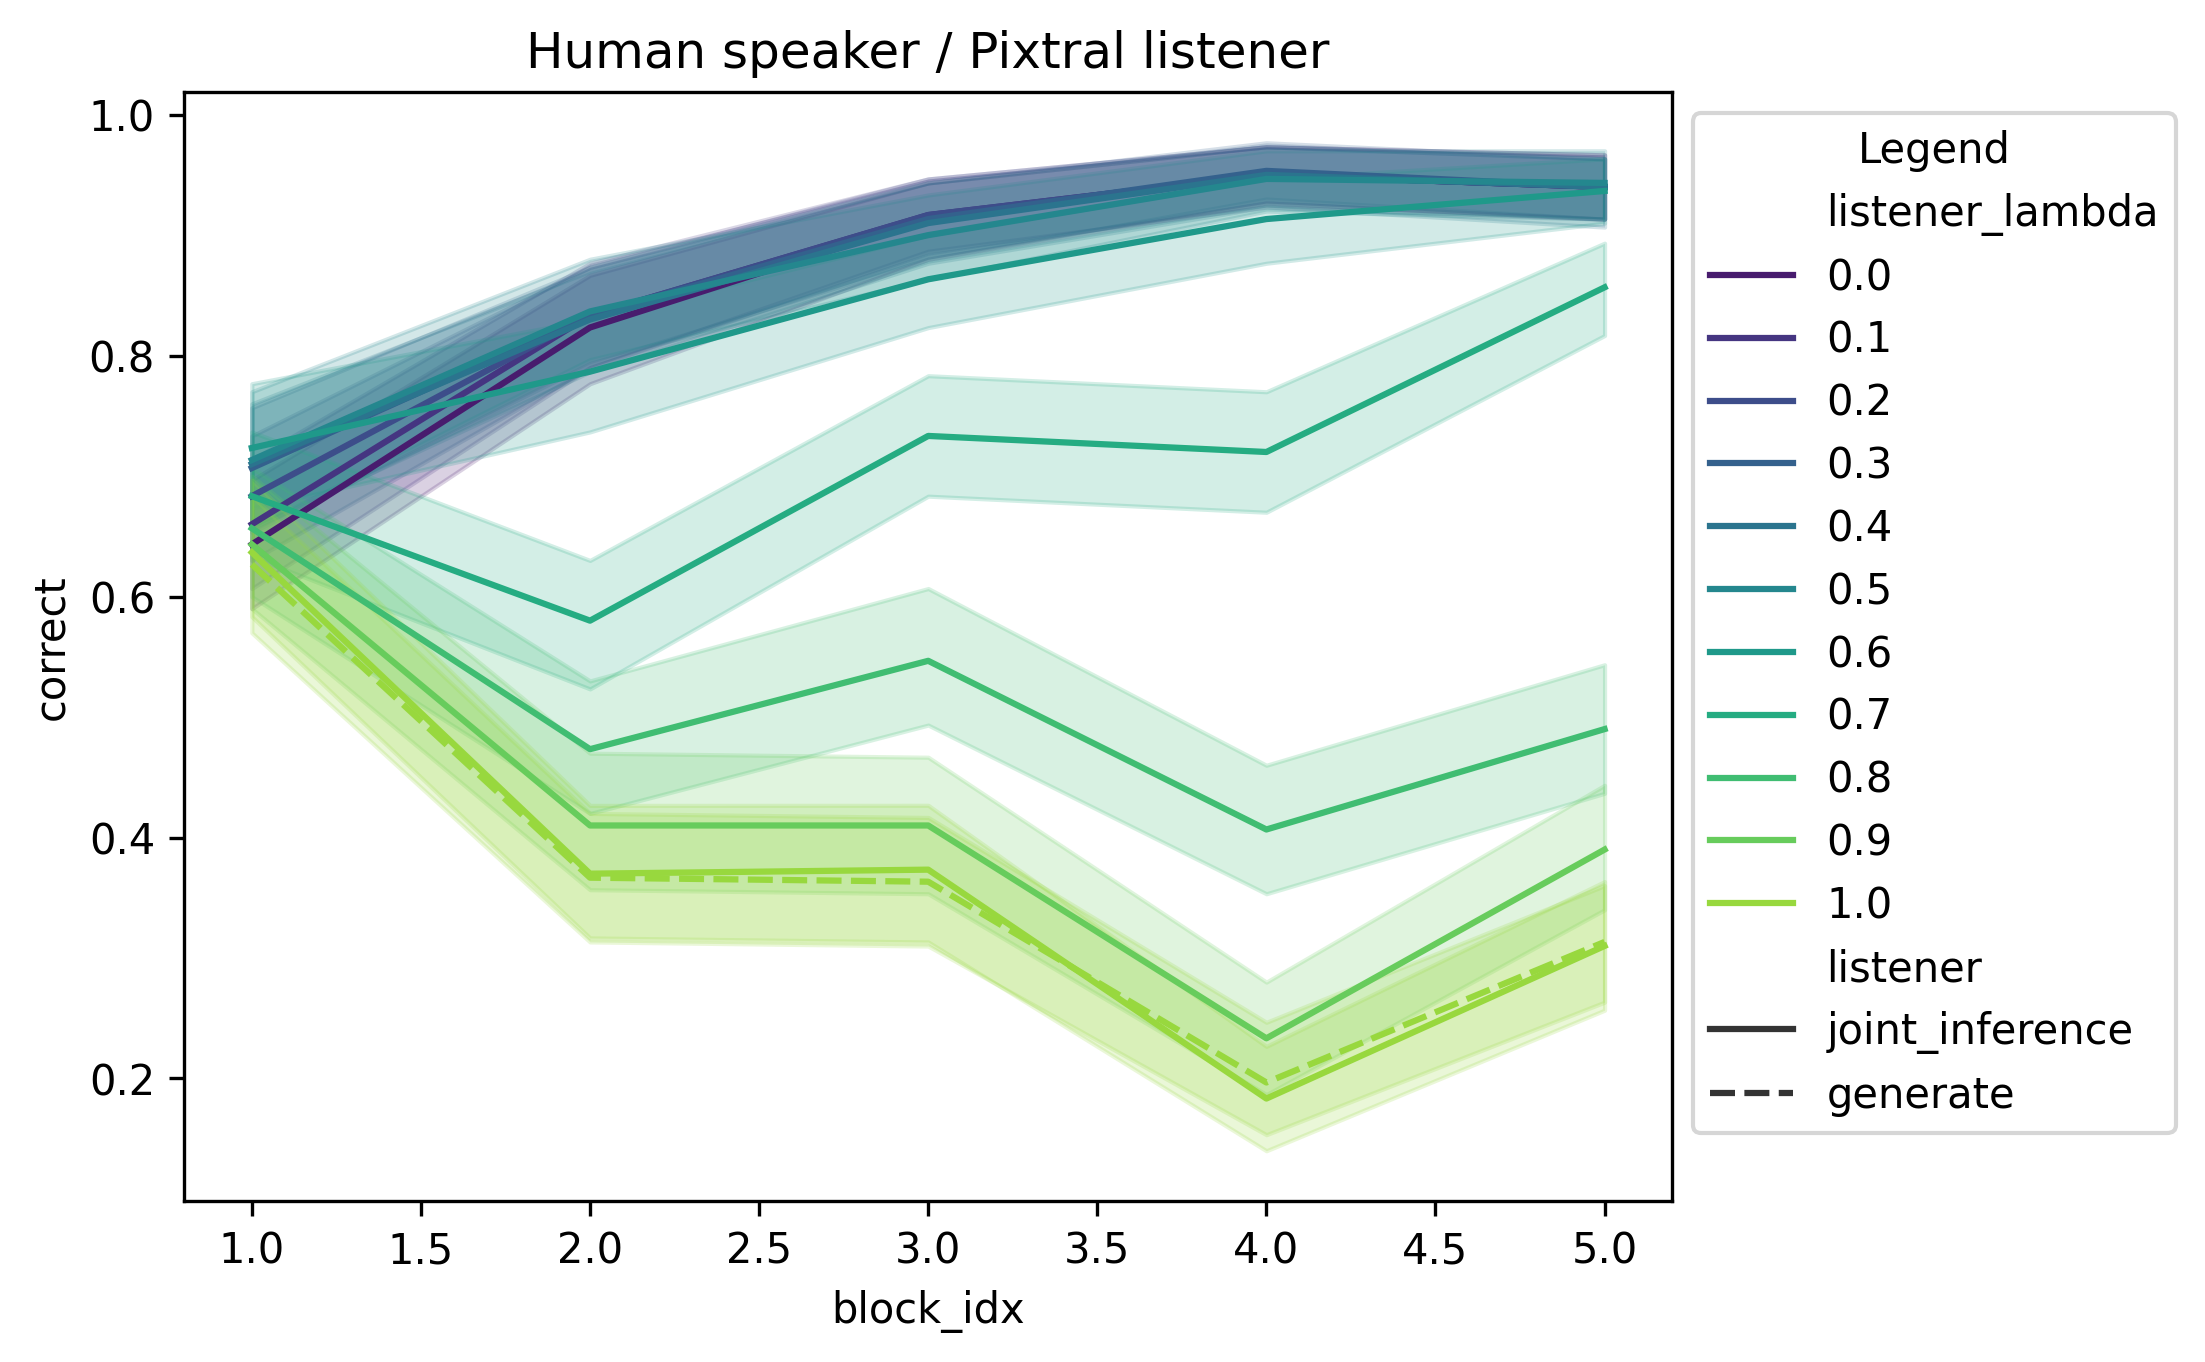

In [22]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[df.condition.isin([ 2,  4,  5,  8, 13, 17, 20, 28, 30, 36, 40, 7])], x="block_idx", y="correct", hue="listener_lambda", style="listener", palette=custom_palette)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Human speaker / Pixtral listener")

/tmp/ipykernel_3681989/2698197571.py:2: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  ax = sns.lineplot(data=df[df.condition.isin([ 9, 15, 24, 25, 29, 38])], x="block_idx", y="correct", hue="listener_lambda", style="listener", palette=custom_palette)


Text(0.5, 1.0, 'Joint inference speaker / Joint inference listener')

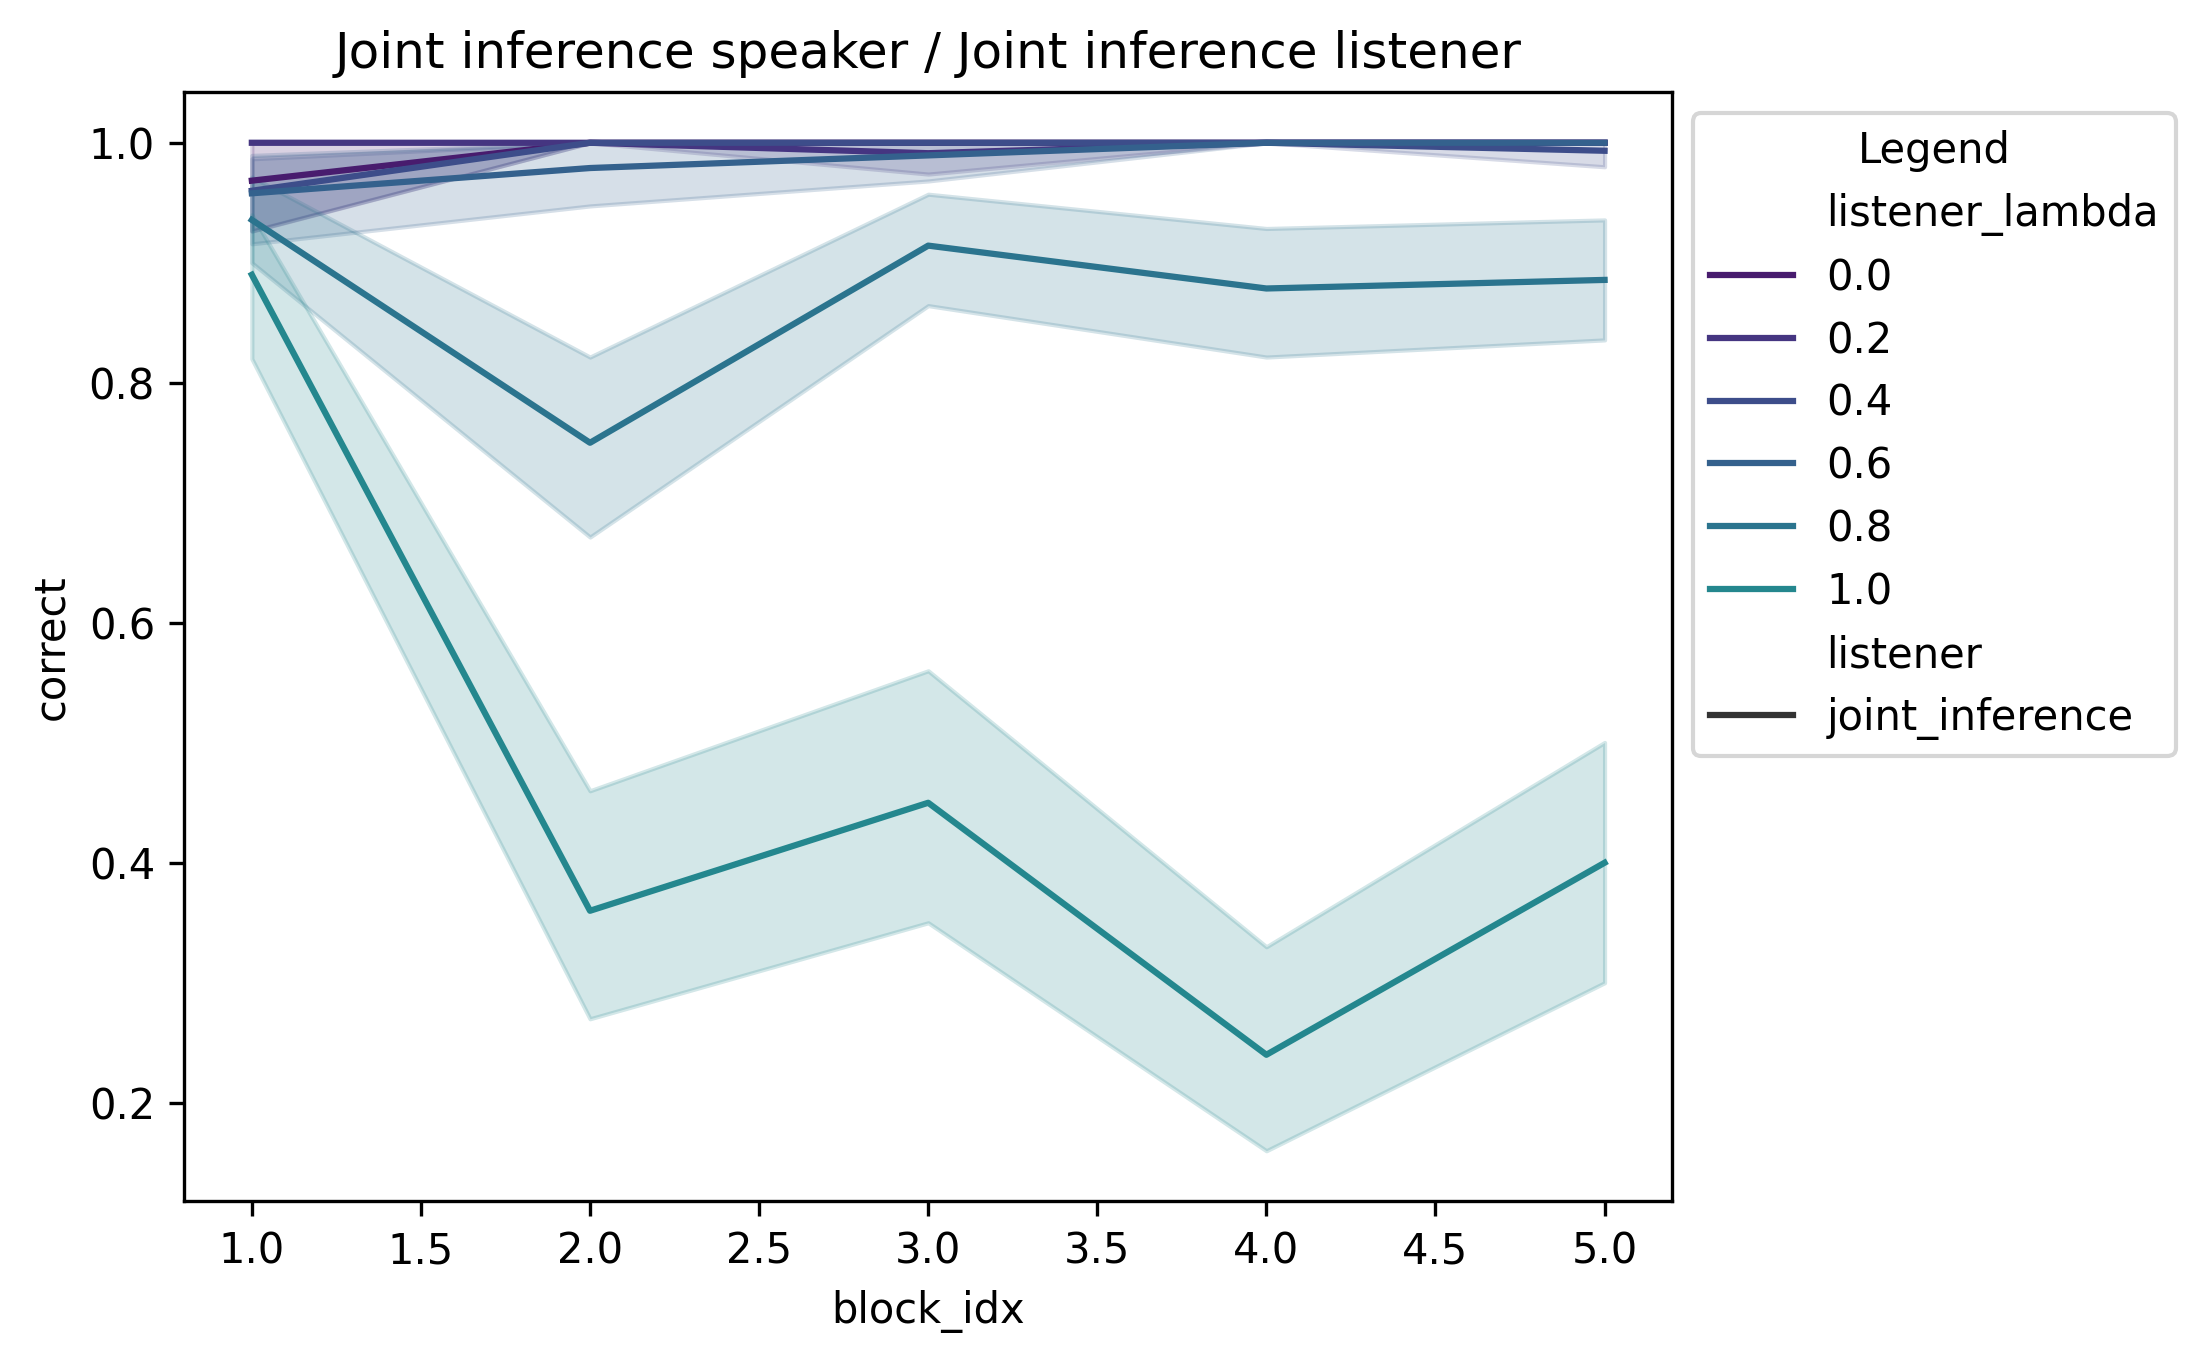

In [30]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[df.condition.isin([ 9, 15, 24, 25, 29, 38])], x="block_idx", y="correct", hue="listener_lambda", style="listener", palette=custom_palette)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Joint inference speaker / Joint inference listener")

/tmp/ipykernel_3681989/2918966217.py:2: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  sns.lineplot(data=df[df.condition.isin([ 0, 19, 31, 35])], x="block_idx", y="num_raw_words", hue="speaker_temp", palette=custom_palette, legend=False)
/tmp/ipykernel_3681989/2918966217.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")


Text(0.5, 1.0, 'Joint inference speaker / Joint inference listener')

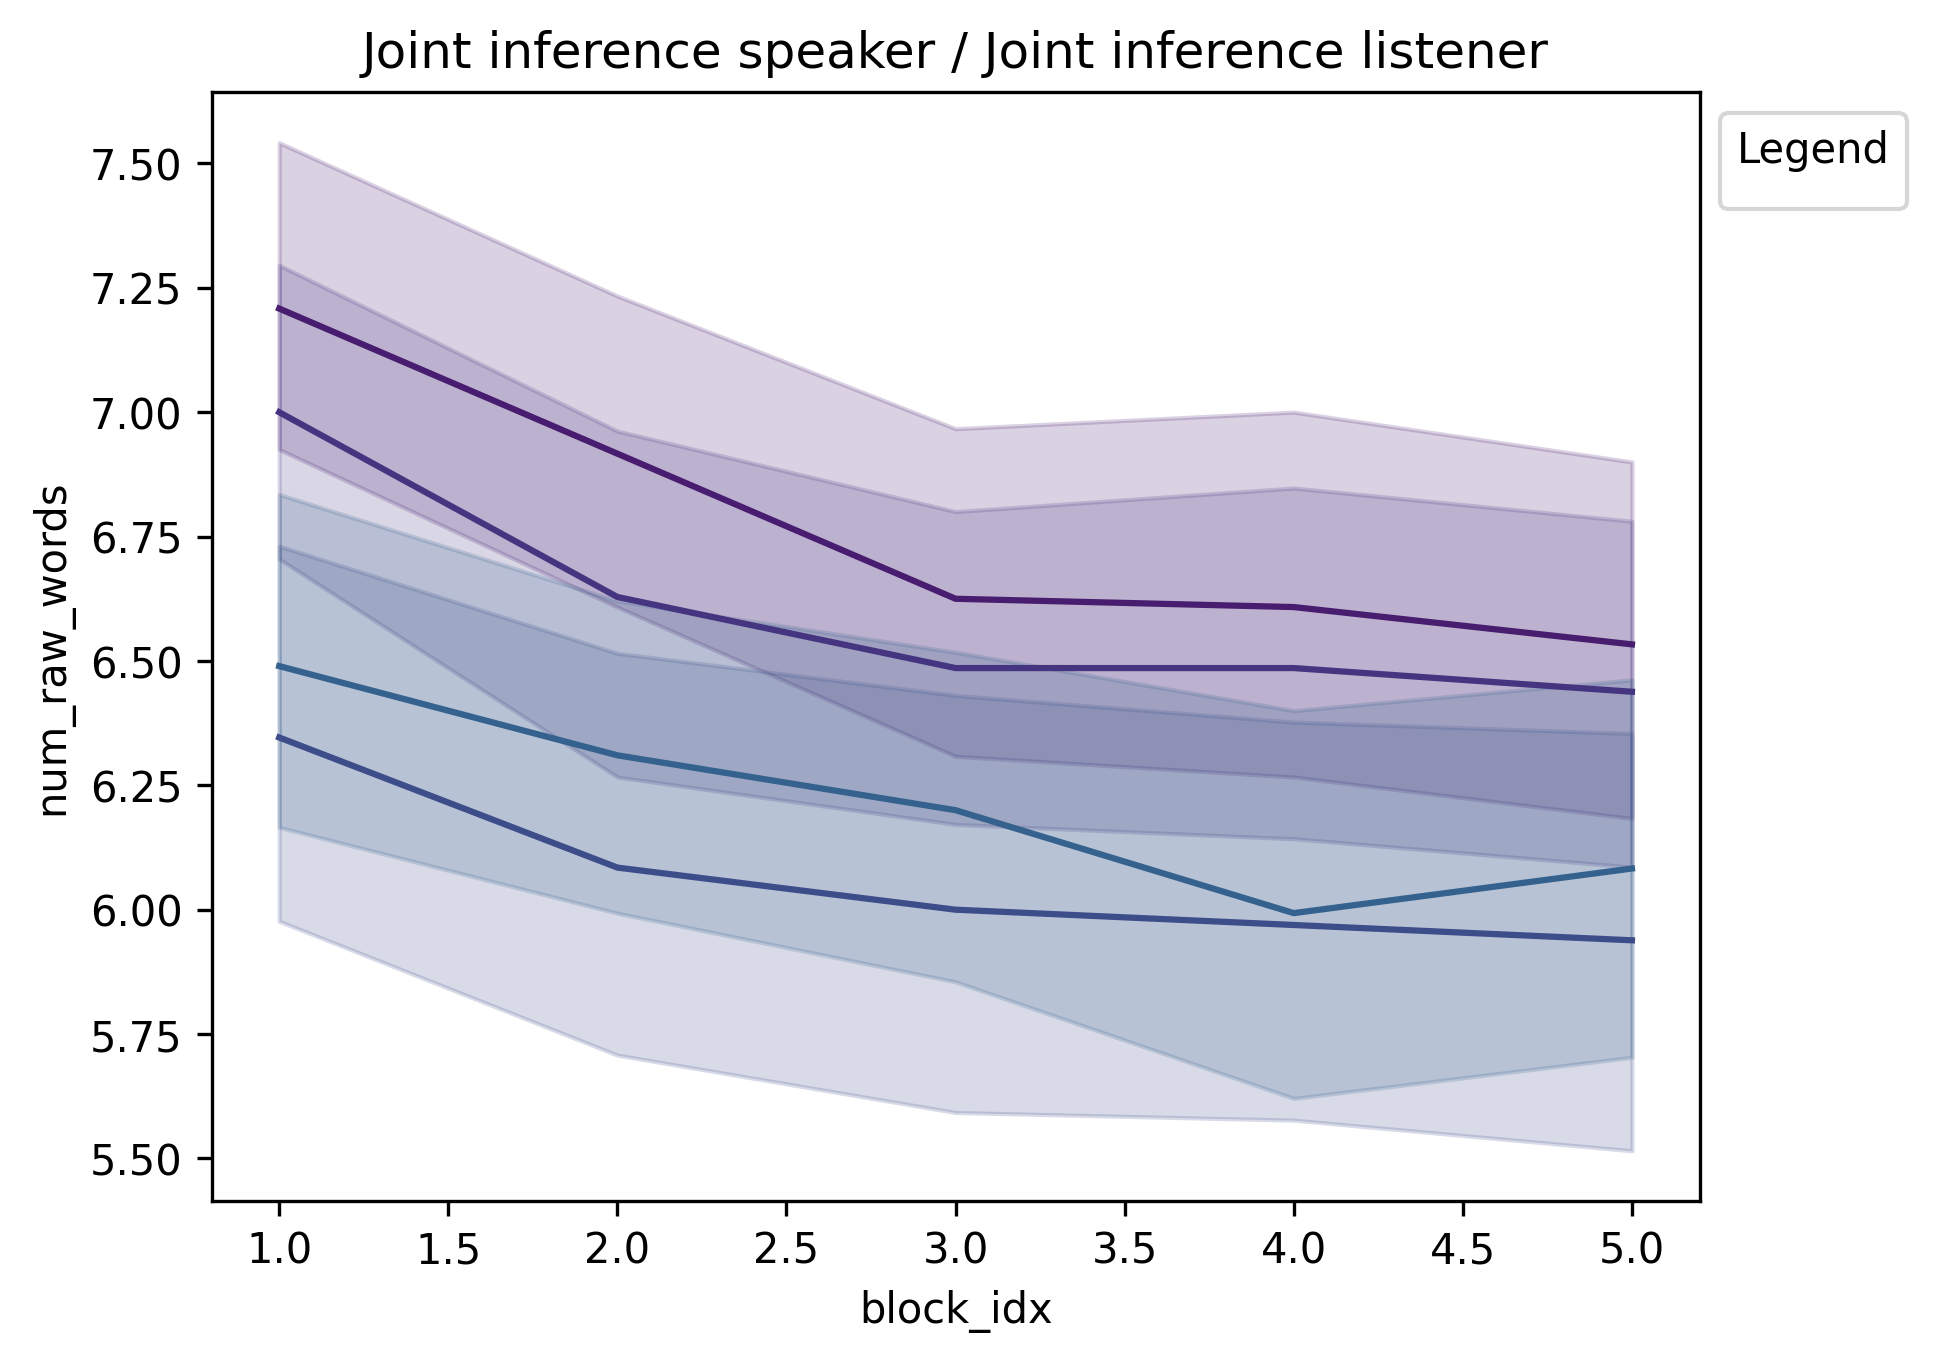

In [47]:
custom_palette = sns.color_palette("viridis", 12)
sns.lineplot(data=df[df.condition.isin([ 0, 19, 31, 35])], x="block_idx", y="num_raw_words", hue="speaker_temp", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Joint inference speaker / Joint inference listener")

/tmp/ipykernel_3681989/2904599514.py:2: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  sns.lineplot(data=df[df.condition.isin([ 0, 19, 31, 35])], x="block_idx", y="wnr", hue="speaker_temp", palette=custom_palette)


Text(0.5, 1.0, 'Joint inference speaker / Joint inference listener')

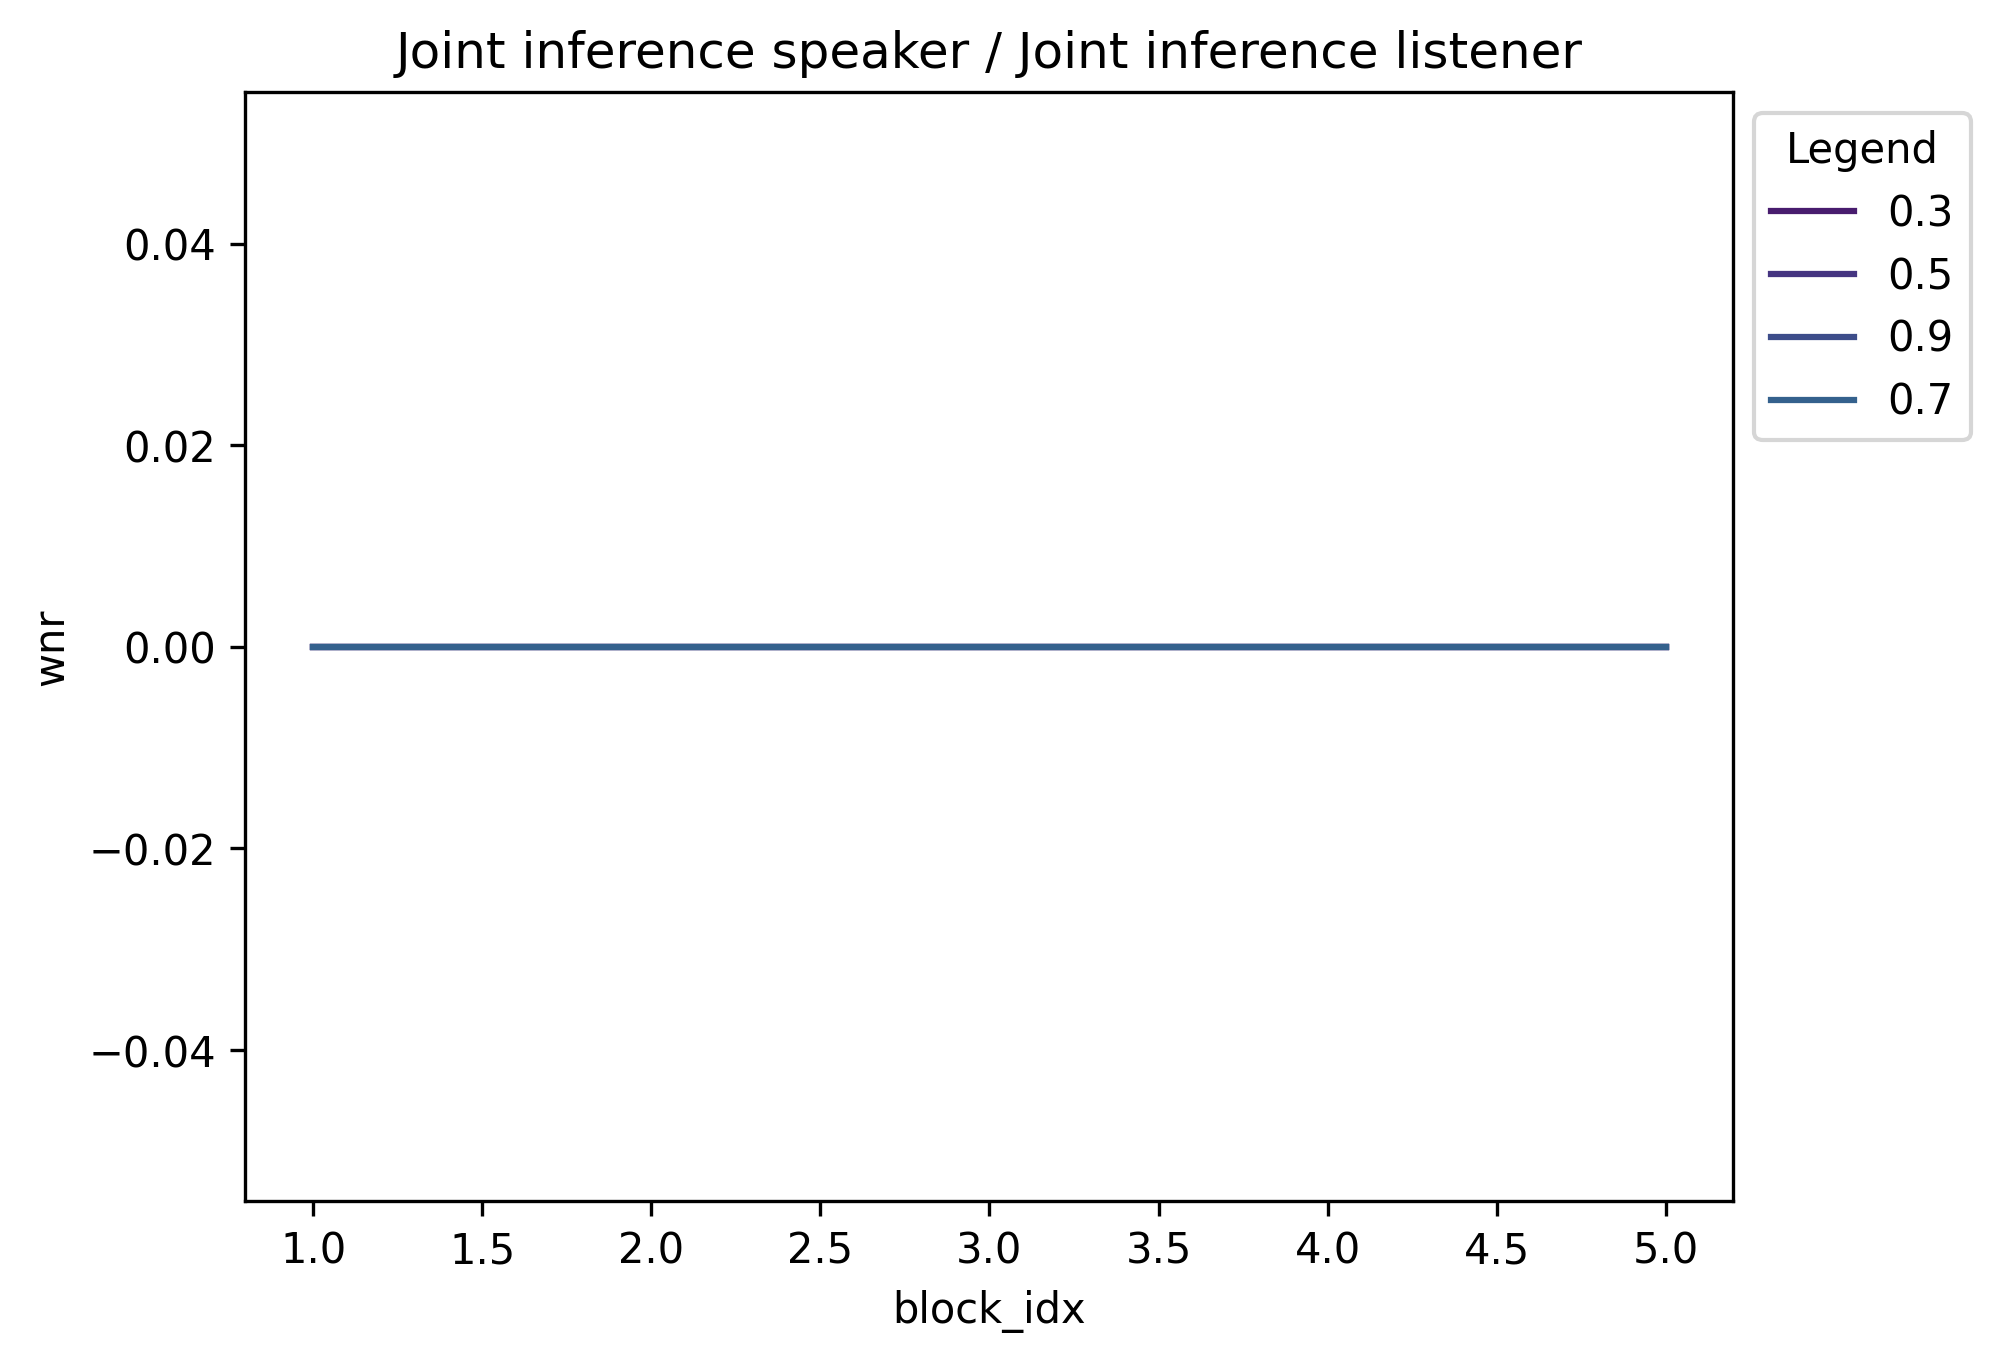

In [48]:
custom_palette = sns.color_palette("viridis", 12)
sns.lineplot(data=df[df.condition.isin([ 0, 19, 31, 35])], x="block_idx", y="wnr", hue="speaker_temp", palette=custom_palette)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Joint inference speaker / Joint inference listener")

Text(0.5, 1.0, 'Human speaker / Pixtral listener')

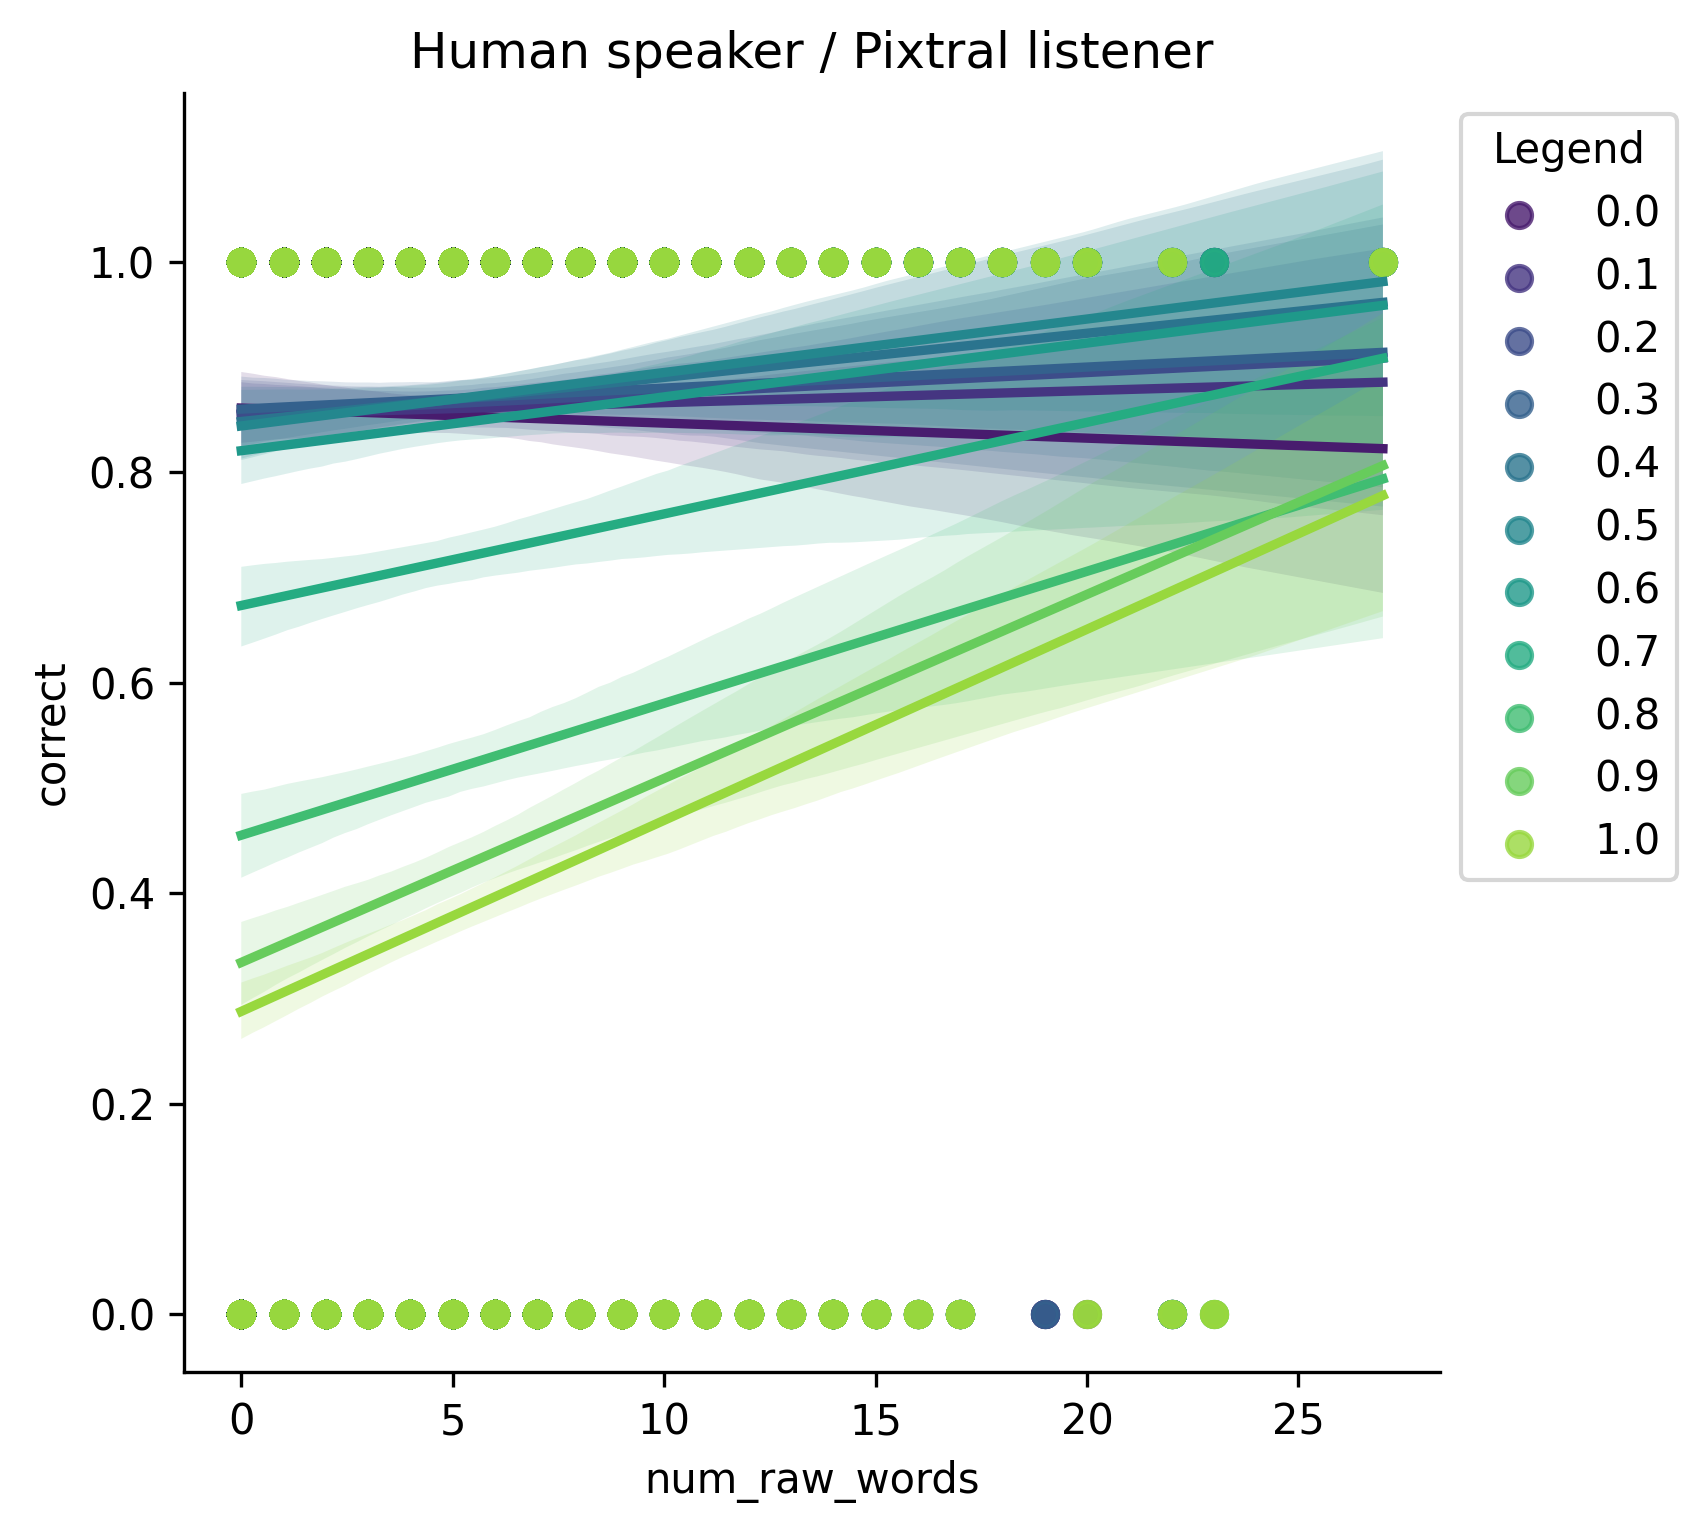

In [51]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([ 2,  4,  5,  8, 13, 17, 20, 28, 30, 36, 40, 7])], x="num_raw_words", y="correct", hue="listener_lambda", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

Text(0.5, 1.0, 'Human speaker / Pixtral listener')

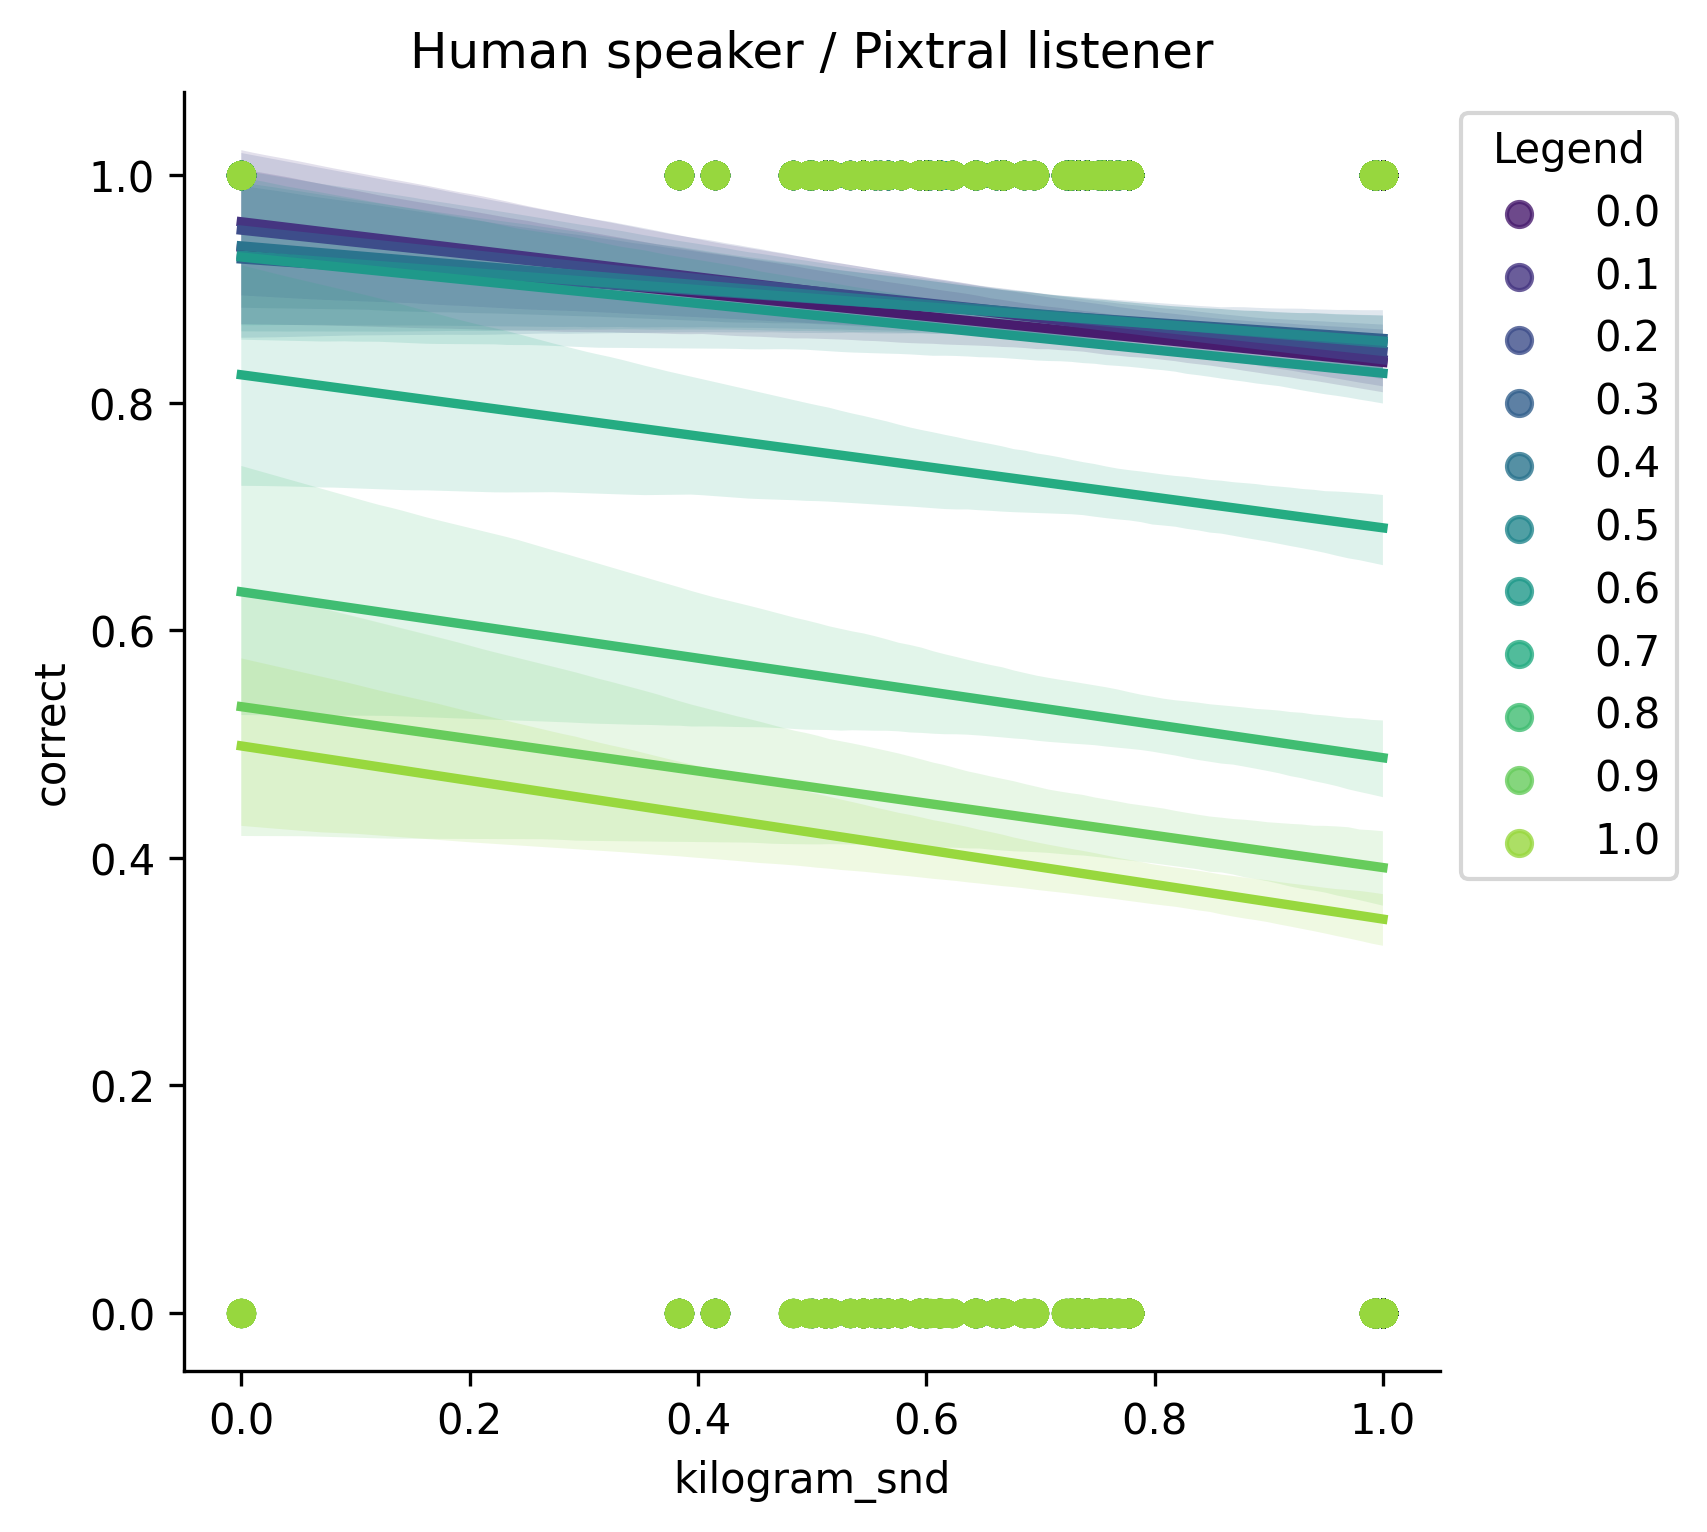

In [52]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([ 2,  4,  5,  8, 13, 17, 20, 28, 30, 36, 40, 7])], x="kilogram_snd", y="correct", hue="listener_lambda", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

Text(0.5, 1.0, 'Pixtral JI speaker / Pixtral listener')

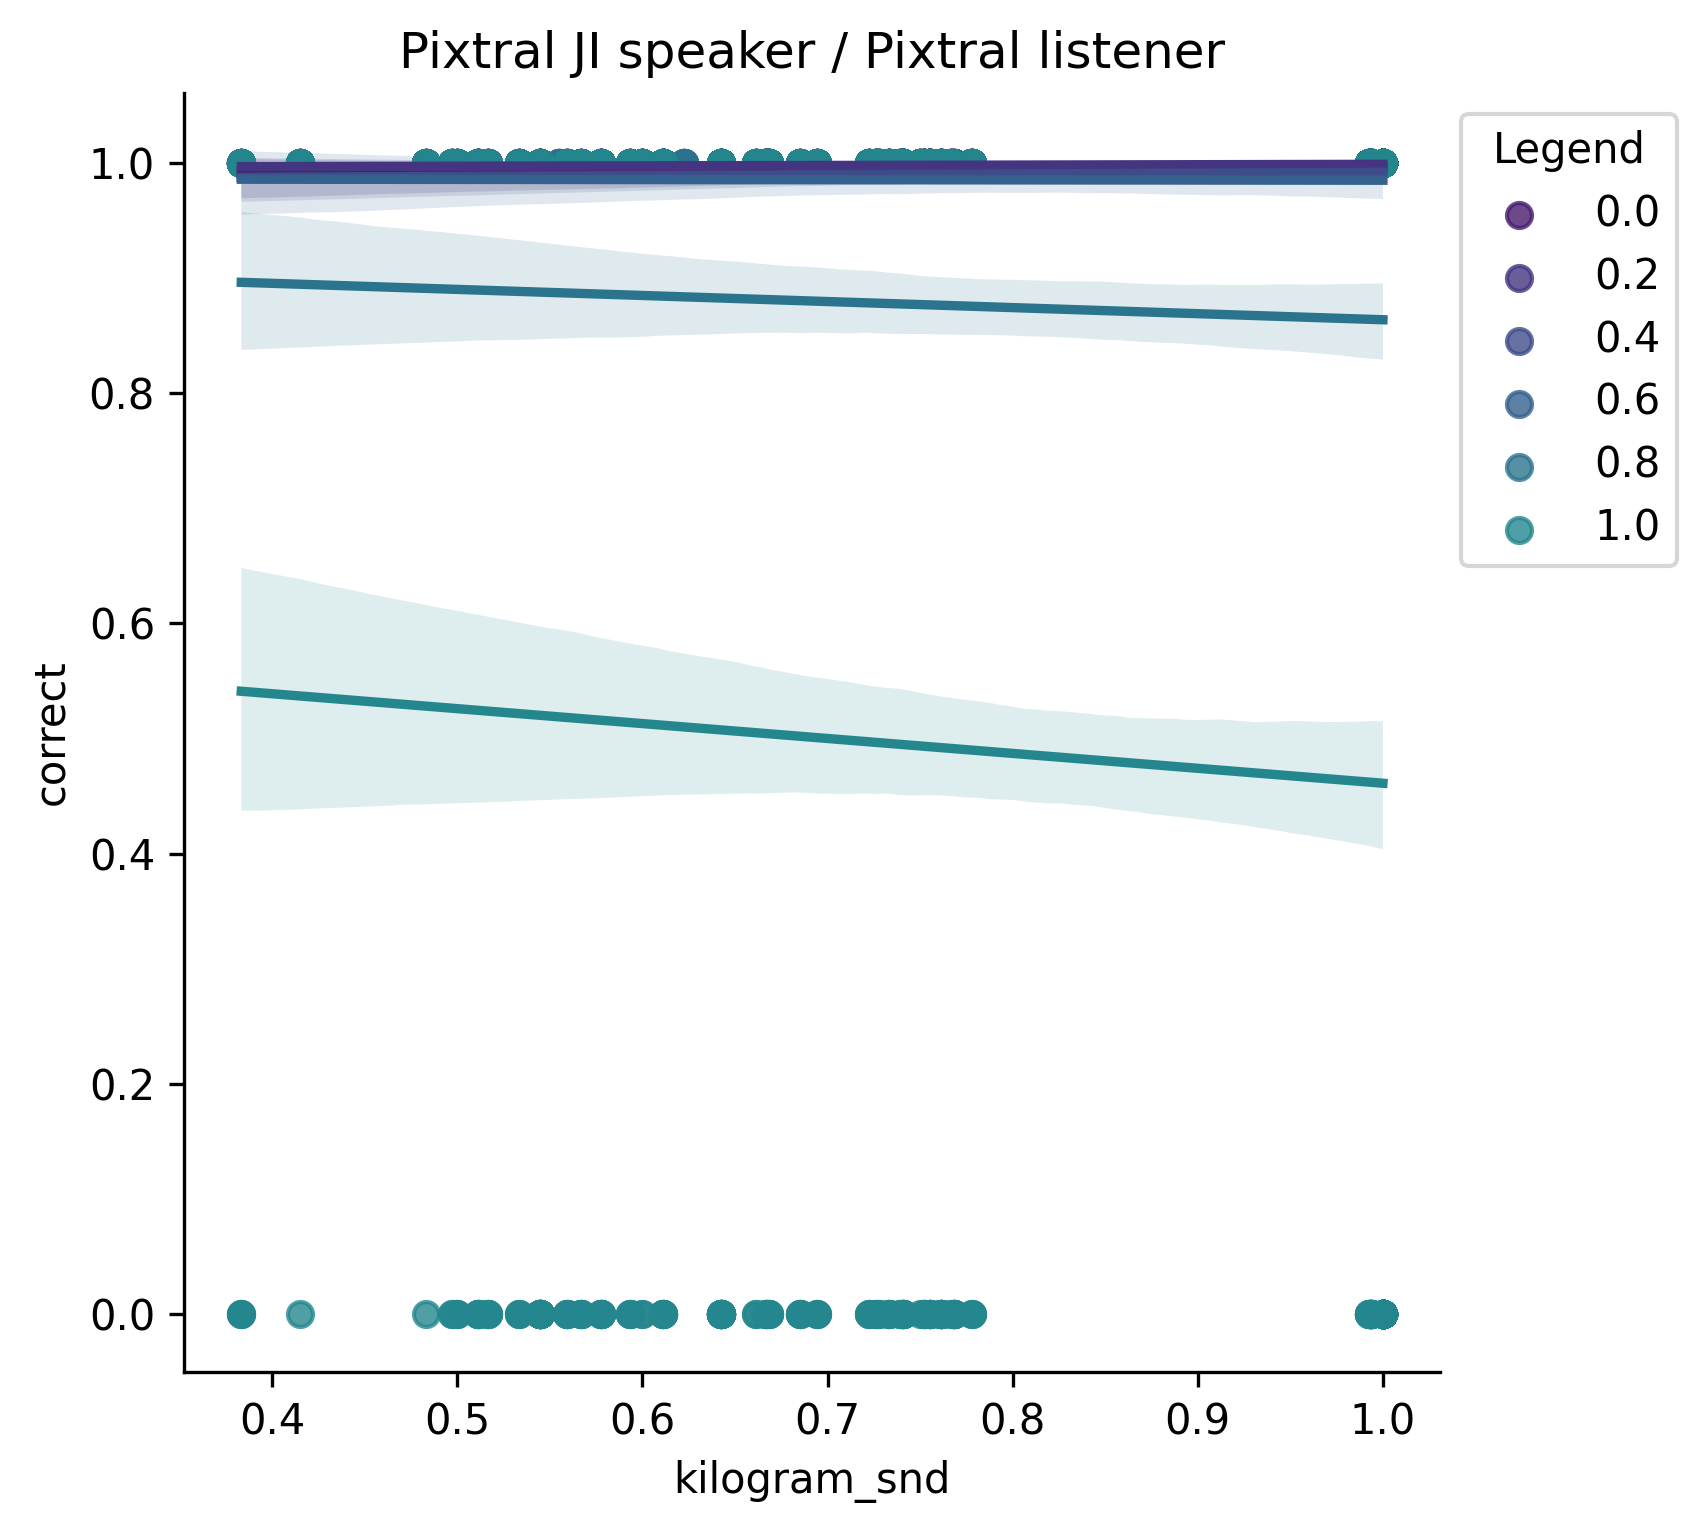

In [55]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([ 9, 15, 24, 25, 29, 38])], x="kilogram_snd", y="correct", hue="listener_lambda", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Pixtral JI speaker / Pixtral listener")

Text(0.5, 1.0, 'Human speaker / Pixtral listener')

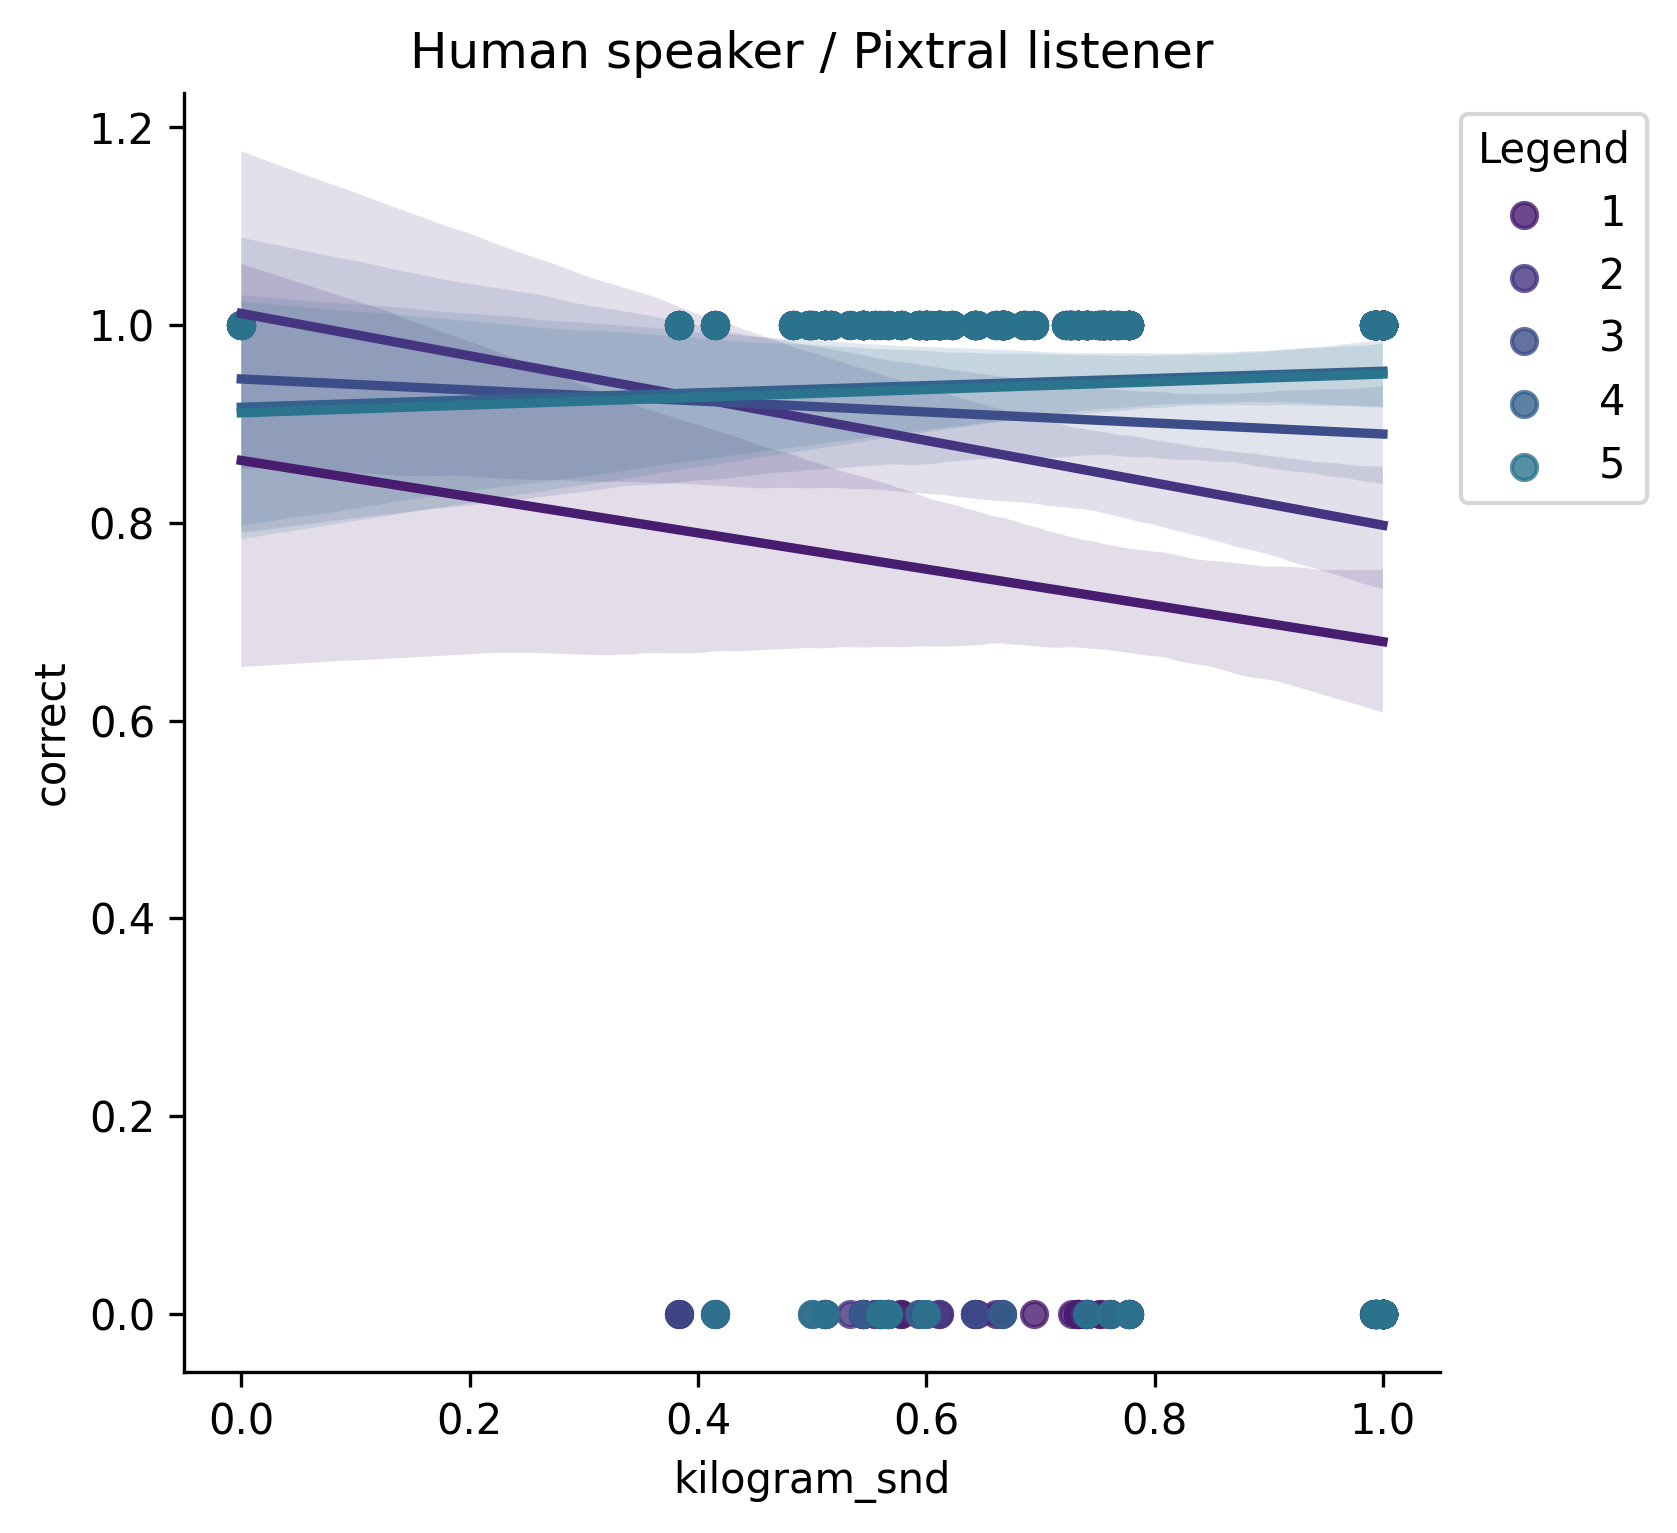

In [53]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([36])], x="kilogram_snd", y="correct", hue="block_idx", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([34])], x="kilogram_snd", y="correct", hue="block_idx", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([34])], x="kilogram_snd", y="correct", hue="listener_lambda", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

Text(0.5, 1.0, 'Joint inference speaker / Joint inference listener')

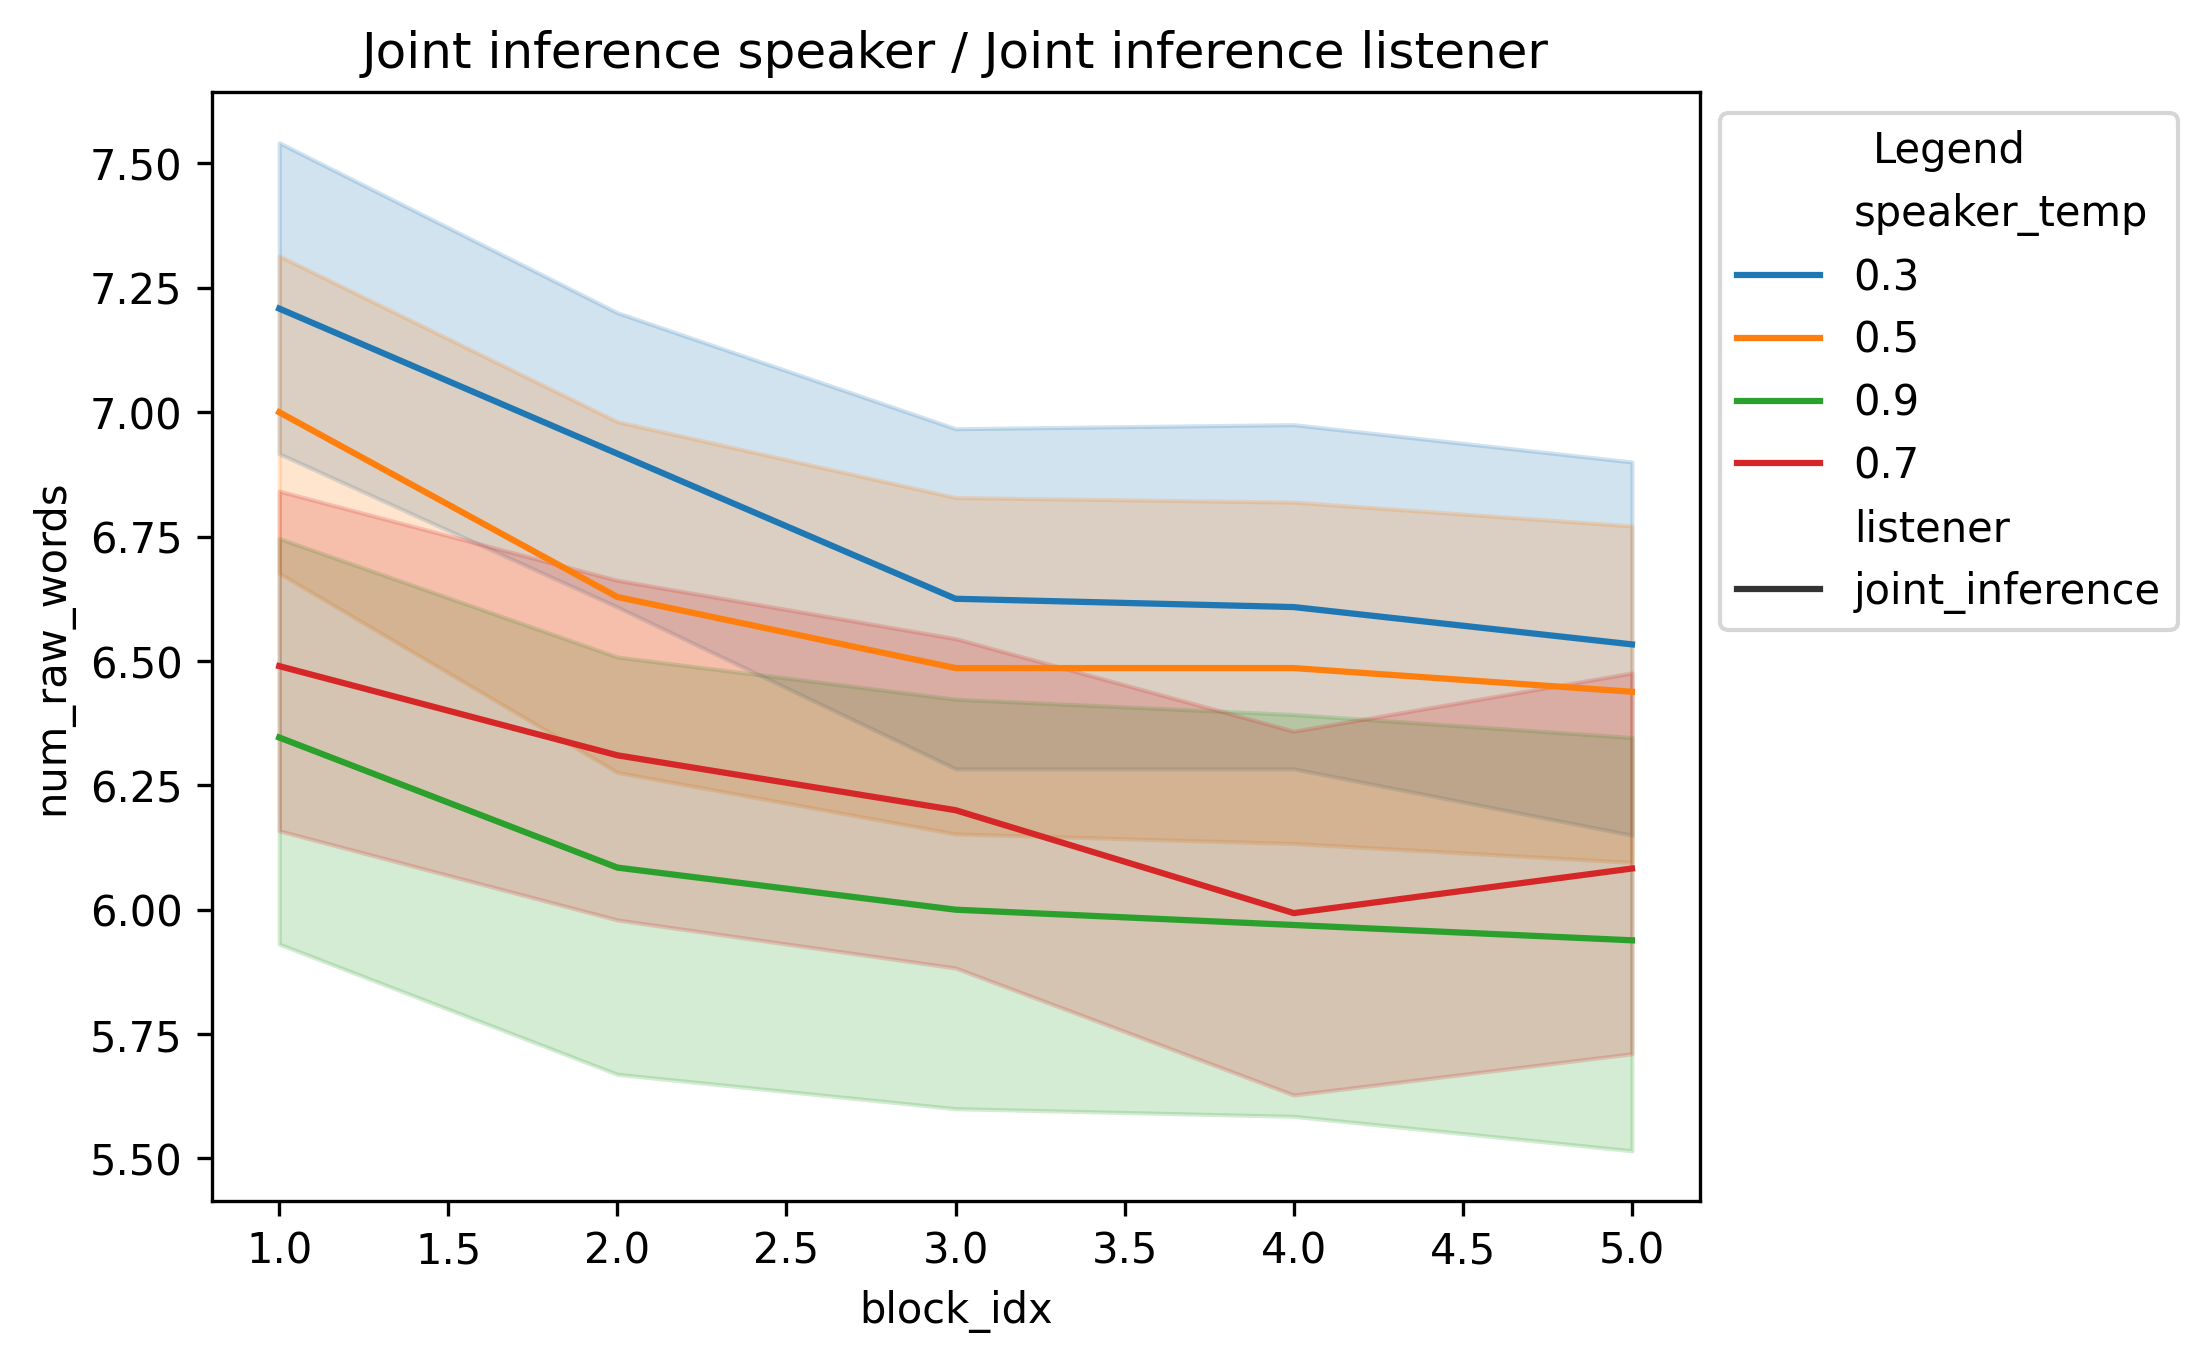

In [37]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[df.condition.isin([ 0, 19, 31, 35])], x="block_idx", y="num_raw_words", hue="speaker_temp", style="listener", palette="tab10")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Joint inference speaker / Joint inference listener")

Text(0.5, 1.0, 'Joint inference speaker / Joint inference listener')

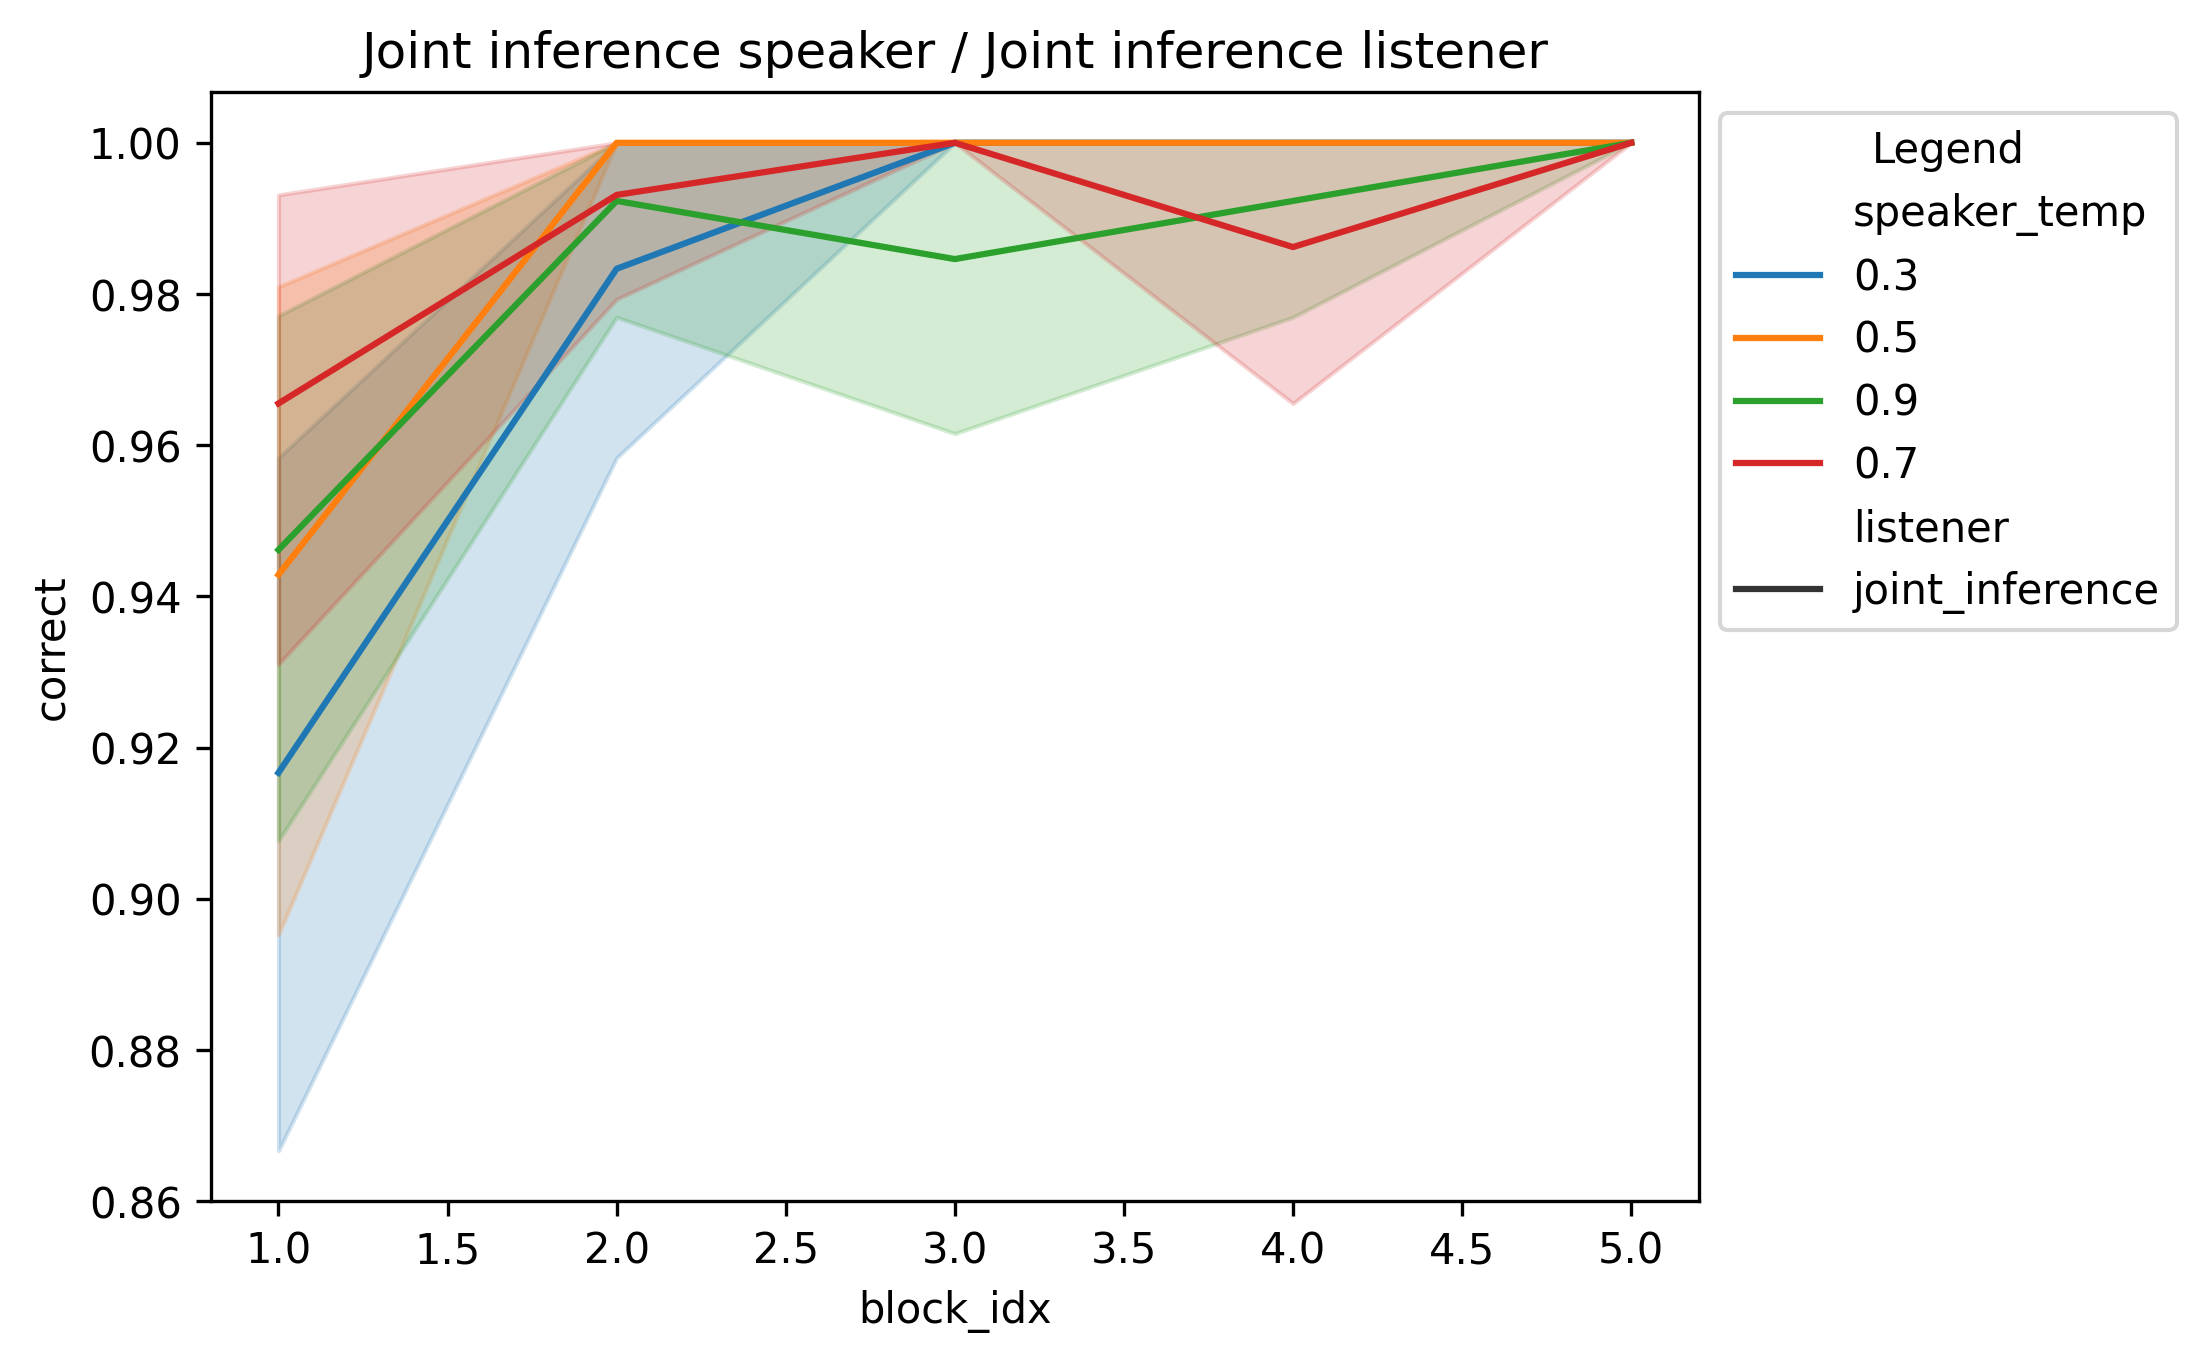

In [40]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[df.condition.isin([0, 19, 31, 35])], x="block_idx", y="correct", hue="speaker_temp", style="listener", palette="tab10")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Joint inference speaker / Joint inference listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[(df.condition.isin([0, 34]))&(df.block_idx > 1)], x="block_idx", y="feedback_adaptation_ratio", hue="speaker", style="prev_block_correct")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Joint inference speaker / Joint inference listener")

In [ ]:
df[df.condition == 34]

In [49]:
df.wnd.unique()

array([0], dtype=uint64)